The following program was written to answer the question "Does Božena Němcová deliberately put softer words at the ends of sentences in her book Babička?" The performance of the algorithm is also analysed.

All raw data used for the project are available for viewing at https://github.com/vk4444/DATA301_Project/tree/main

**AI usage disclosure:**
LLMs were used rarely throughout this project and never to generate larger blocks of text or code. All searches and prompts can be found in the Searches Documentation document which was attached to the assignment submission.

# Installations

In [ ]:
!pip install -U pypdfium2
!pip install "dask[distributed]"
!pip install scipy

,  Downloading pypdfium2-5.8.0-py3-none-manylinux_2_17_x86_64.manylinux2014_x86_64.whl.metadata (68 kB)
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 68.4/68.4 kB 2.3 MB/s eta 0:00:00
,Downloading pypdfium2-5.8.0-py3-none-manylinux_2_17_x86_64.manylinux2014_x86_64.whl (3.7 MB)
,   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.7/3.7 MB 38.8 MB/s eta 0:00:00
,Installing collected packages: pypdfium2
,Successfully installed pypdfium2-5.8.0
,Requirement already satisfied: dask[distributed] in /usr/local/lib/python3.12/dist-packages (2026.3.0)
,Requirement already satisfied: click>=8.1 in /usr/local/lib/python3.12/dist-packages (from dask[distributed]) (8.4.0)
,Requirement already satisfied: cloudpickle>=3.0.0 in /usr/local/lib/python3.12/dist-packages (from dask[distributed]) (3.1.2)
,Requirement already satisfied: fsspec>=2021.09.0 in /usr/local/lib/python3.12/dist-packages (from dask[distributed]) (2025.3.0)
,Requirement already satisfied: packaging>=20.0 in /usr/local/lib/python3.12/dist-p

# Imports

In [ ]:
import dask.bag as db
import dask.dataframe as ddf
import dask.array as da
import pandas as pd
import numpy as np
import pypdfium2 as pdfium
import re
import time
import random
import math
from scipy import stats
from dask.diagnostics import ProgressBar
from google.colab import output
import matplotlib.pyplot as plt

# Global Declarations

In [ ]:
# ensures reproducibility of results
random.seed(42)

# used later when deciding which book is compared to the other books and wikipedia
examined_book = 'babicka_bozena_nemcova'

# number of 1MB wikipedia files loaded
wiki_sample_size = 20


# Load datasets into the notebook

Cloning usually takes under 1 minute and is necessary for compatibility:

In [ ]:
!git clone https://github.com/vk4444/DATA301_Project.git

Cloning into 'DATA301_Project'...
,remote: Enumerating objects: 1705, done.
,remote: Counting objects: 100% (74/74), done.
,remote: Compressing objects: 100% (72/72), done.
,remote: Total 1705 (delta 21), reused 1 (delta 1), pack-reused 1631 (from 3)
,Receiving objects: 100% (1705/1705), 717.56 MiB | 42.37 MiB/s, done.
,Resolving deltas: 100% (85/85), done.
,Updating files: 100% (1409/1409), done.


In [ ]:
book_file_names = ['babicka_bozena_nemcova',
'windows8_redakce_businessIT_a_partneri',
'cesky_rozhlas-historie_eva_jesutova_a_kolektiv',
'flvek_05_alois_jirasek',
'flvek_4_alois_jirasek',
'flvek_03_alois_jirasek',
'flvek_02_alois_jirasek',
'flvek_01_alois_jirasek',
'jihoslovanske_jazyky_pavel_krejci',
'nase_nynejsi_krise_tomas_garrigue_masaryk',
'lucerna_alois_jirasek',
'matka_karel_capek',
'basne_josef_vaclav_sladek',
'dalimilova_kronika_dalimil',
'obycejny_zivot_karel_capek',
'povetron_karel_capek',
'hordubal_karel_capek',
'noc_na_karlstejne_jaroslav_vrchlicky',
'pisne_kosmicke_jan_neruda',
'domaci_kucharka_magdalena_dobromila_rettigova',
'hovory_s_tg_masarykem_karel_capek',
'dramaticke_zlomky_karel_hynek_macha',
'povidani_o_pejskovi_a_kocicce_josef_capek',
'obrazy_z_dejin_naroda_ceskeho_iii_vladislav_vancura',
'obrazy_z_dejin_naroda_ceskeho_ii_vladislav_vancura',
'obrazy_z_dejin_naroda_ceskeho_i_vladislav_vancura',
'rur_karel_capek',
'bylo_nas_pet_karel_polacek',
'mistr_kampanus_zikmund_winter',
'konec_starych_casu_vladislav_vancura',
'ballady_a_romance_jan_neruda',
'vec_makropulos_karel_capek',
'krakatit_karel_capek',
'filosofska_historie_alois_jirasek',
'stare_povesti_ceske_alois_jirasek',
'devatero_pohadek_karel_capek',
'kosmuw_letopis_cesky_kosmas',
'tezka_hodina_jiri_wolker',
'host_do_domu_jiri_wolker',
'nova_evropa_tomas_garrigue_masaryk',
'sedm_let_v_jizni_africe_iv_emil_holub',
'sedm_let_v_jizni_africe_iii_emil_holub',
'sedm_let_v_jizni_africe_druha_cesta_emil_holub',
'sedm_let_v_jizni_africe_prvni_cesta_emil_holub',
'bila_nemoc_karel_capek',
'rozmarne_leto_vladislav_vancura',
'maj_karel_hynek_macha',
'kytice_karel_jaromir_erben',
'osudy_dobreho_vojaka_svejka_jaroslav_hasek_volumes3and4',
'osudy_dobreho_vojaka_svejka_jaroslav_hasek_volumes1and2',
'broucci_jan_karafiat',
]

## Utility Functions

**book_loader:** The function takes a file name, and uses pdfium, to extract the text from it. Pdfium has known issues with parallel processing, so some functionalities, such as dask.distributed computing is not available. First it looks for a "version marker" which indicates the last page of cover and publication info pages. Afterwards, it looks if the next page is table of contents, and if it is, it skips it too. Then the text from each page is extracted and added to a string variable. In the end the tuple (filename, text) is returned.

**generate_wiki_urls:** the function generates all the urls to the wikipedia files. The entire wikipedia is separated into 1MB large chunks. In the wikipedia folder, folders are named AA, AB, AC... and each contains up to 100 files names 00, 01, 02 ... 99. (to see how the files were obtained using wikiextractor, please refer to the section [Separately Used Scripts](#scrollTo=-KH5D1vR7Flh&line=1&uniqifier=1)) please see the The function only takes the last used letter in the folder structure and the last number in the last folder. It also takes sample size as an argument, and using `random.sample()` samples the paths. In the end, the list of pats is returned.



In [ ]:
# loads books and converts from pdf to txt
def book_loader(filename: str) -> tuple[str, str]:
  document = pdfium.PdfDocument('DATA301_Project/books/' + filename + '.pdf')

  version_marker_found = 0
  book_started = 0
  text = ''
  for page in document:
    # extract text from the page
    textpage = page.get_textpage()
    extractedtext = textpage.get_text_bounded()

    # the following two conditions ensure that the material attached to the book that is not a part of the original text is skipped (for example the cover page, info about publication etc.)
    if version_marker_found == 0 and 'verze' in extractedtext.lower():
      version_marker_found = 1
      print('version marker found')

    # after the version marker is found (indicating the last page of added material), the next page is checked for containing the contents (obsah) of the book which can also be skipped.
    elif version_marker_found and book_started == 0:
      if 'obsah' not in extractedtext.lower():
        book_started = 1

    if book_started:
      text += extractedtext

  return filename, text

# generates urls for all the wiki files
def generate_wiki_urls(last_chr: str = 'N', last_number: int = 55, sample_size: int = 0) -> list[str]:
  urls = []
  current_chr = 'A'
  current_num_str = '00'

  # generates urls for all the files
  while ord(current_chr) <= ord(last_chr):
    n_of_files = 100

    if ord(current_chr) == ord(last_chr):
      n_of_files = last_number + 1

    for i in range(n_of_files):
      if i < 10:
        current_num_str = '0' + str(i)
      else:
        current_num_str = str(i)

      urls.append('DATA301_Project/wiki/A' + current_chr + '/' + 'wiki_' + current_num_str)

    current_chr = chr(ord(current_chr) + 1)

  if sample_size:
    urls = random.sample(urls, k=sample_size)

  return urls

In [ ]:
# wiki loader samples correctly
assert len(generate_wiki_urls(sample_size=100)) == 100

## Loading the Data
The books and wiki were loaded in parallel into bags using the `from_sequence()` and `read_text()` Dask Bag methods. Then an important step of repartitioning has been added to improve performance (see [Resolving Performance Issues](#scrollTo=tkftaL1wygC9)).

The results of a survey examining subjective perceptions of softness is loaded into a Dask Dataframe. Please see the section [Survey](#scrollTo=KtGgFQiadWnU&line=6&uniqifier=1), for more information.

In [ ]:
# load the books
books = db.from_sequence(book_file_names).map(book_loader)

# load the Czech Wikipedia
wiki = (
    db.read_text(generate_wiki_urls(sample_size=wiki_sample_size))
    .filter(lambda x: x[:4] != '<doc' and '__NOEDITSECTION__' not in x and '</doc>' not in x)
    .map(lambda x: ('wiki', x))
)

books = books.repartition(npartitions=2)
wiki = wiki.repartition(npartitions=int(wiki_sample_size/100) + 1)

survey_anonymized = ddf.read_csv('DATA301_Project/survey/anonymized_data.csv', na_values=['<NA>'])

all_text = db.concat([wiki, books])

One bottleneck that has been identified throughout the process is the loading of wikipedia (see [Resolving Performance Issues](#scrollTo=tkftaL1wygC9)). The following bar helps assess whether wikipedia is loading fast enough given the sample size.

In [ ]:
with ProgressBar():
  result = wiki.compute()

[########################################] | 100% Completed | 2.60 s


In [ ]:
# look at the first item of the raw loaded books
print(books.take(1))

In [ ]:
# look at the first few items of the raw loaded wikipedia
print(wiki.take(3))

(('wiki', 'Vlajka Marshallových ostrovů\n'), ('wiki', '\n'), ('wiki', 'Vlajka Marshallových ostrovů je tvořena tmavě modrým listem o poměru stran 1:2 (původně 10:19, podle vlajky USA) se dvěma kosými, vějířovitě se rozšiřujícími pruhy, směřujícími z dolního rohu do horního cípu (viz vexilologické názvosloví). Horní trojúhelník je oranžový, dolní je bílý. V žerďovém poli je bílá hvězda se čtyřiadvaceti cípy. Čtyři z cípů jsou delší a směřují k okrajům listu.\n'))


In [ ]:
# look at the first few rows of the raw survey
survey_anonymized.head()

,Unnamed: 0,StartDate,EndDate,Status,IPAddress,Progress,Duration (in seconds),Finished,RecordedDate,ResponseId,...,A19_1,A20_1,A21_1,A22_1,A23_1,A24_1,A25_1,A26_1,A27_1,A28_1
0,0,Start Date,End Date,Response Type,anonymized,Progress,Duration (in seconds),Finished,Recorded Date,Response ID,...,Focus on the consonant in the audio. How soft ...,Focus on the consonant in the audio. How soft ...,Focus on the consonant in the audio. How soft ...,Focus on the consonant in the audio. How soft ...,Focus on the consonant in the audio. How soft ...,Focus on the consonant in the audio. How soft ...,Focus on the consonant in the audio. How soft ...,Focus on the consonant in the audio. How soft ...,Focus on the consonant in the audio. How soft ...,Focus on the consonant in the audio. How soft ...
1,1,"{""ImportId"":""startDate"",""timeZone"":""America/De...","{""ImportId"":""endDate"",""timeZone"":""America/Denv...","{""ImportId"":""status""}",anonymized,"{""ImportId"":""progress""}","{""ImportId"":""duration""}","{""ImportId"":""finished""}","{""ImportId"":""recordedDate"",""timeZone"":""America...","{""ImportId"":""_recordId""}",...,"{""ImportId"":""QID23_1""}","{""ImportId"":""QID24_1""}","{""ImportId"":""QID25_1""}","{""ImportId"":""QID26_1""}","{""ImportId"":""QID27_1""}","{""ImportId"":""QID28_1""}","{""ImportId"":""QID29_1""}","{""ImportId"":""QID30_1""}","{""ImportId"":""QID31_1""}","{""ImportId"":""QID32_1""}"
2,2,2026-05-10 17:11:47,2026-05-10 17:13:19,Survey Preview,anonymized,100,91,True,2026-05-10 17:13:19,R_4JE55jXT7iFK35L,...,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>
3,3,2026-05-10 18:20:56,2026-05-10 18:26:17,IP Address,anonymized,100,320,True,2026-05-10 18:26:18,R_9ZV8QTRGmaUyEur,...,87,87,80,75,68,77,<NA>,19,61,77
4,4,2026-05-10 18:37:15,2026-05-10 18:43:13,IP Address,anonymized,100,358,True,2026-05-10 18:43:14,R_9M4FuHomfPqmXye,...,61,63,22,38,71,70,65,86,95,95


# Data Pre-processing

## Dictionnary of Abbreviations

This is the dictionnary of abbreviations that will be expanded. This is done so that the text corresponds to how it would be pronounced and to correctly separate the sentences later. The dictionnary was adapted from https://cja.ujc.cas.cz/e-cja/zkratky which lists some of the most common abbreviations in the Czech Language. The dictionnary is not exhaustive and some of the abbreviations might have different interpretations in certain contexts.

In [ ]:
#adapted from https://cja.ujc.cas.cz/e-cja/zkratky
abbr_dict = {
    "adj.": "adjektivum",
    "adv.": "adverbium",
    "aj.": "a jiné",
    "akuz.": "akuzativ",
    "apod.": "a podobně",
    "atd.": "a tak dále",
    "býv.": "bývalý",
    "č.": "č",
    "čes.": "český",
    "dat.": "dativ",
    "dolož.": "doloženo",
    "doudl.": "doudlebský",
    "dř.": "dříve",
    "f.": "femininum",
    "gen.": "genitiv",
    "imp.": "imperativ",
    "ind.": "indikativ",
    "inf.": "infinitiv",
    "inform.": "informátor",
    "instr.": "instrumentál",
    "jč.": "jihočeský",
    "již.": "jižní",
    "jjv.": "jihojihovýchodní",
    "jjz.": "jihojihozápadní",
    "jv.": "jihovýchod",
    "jz.": "jihozápad",
    "jzč.": "jihozápadočeský",
    "km": "kilometr",
    "kol.": "kolektiv",
    "kond.": "kondicionál",
    "lid.": "lidový",
    "lok.": "lokál",
    "m.": "maskulinum",
    "m n. m.": "metry nad mořem",
    "min.": "minulý",
    "n. l.": "našeho letopočtu",
    "např.": "například",
    "nar.": "narozen",
    "nář.": "nářečí",
    "nepřízv.": "nepřízvučný",
    "neživ.": "neživotný",
    "nom.": "ominativ",
    "obl.": "oblast",
    "obyv.": "obyvatel",
    "okr.": "okres",
    "os.": "osoba",
    "pl.": "plurál",
    "plt.": "plurale tantum",
    "poč.": "počátek",
    "popř.": "popřípadě",
    "préz.": "prézens",
    "protet.": "protetický",
    "předp.": "předpona",
    "přech.": "přechodník",
    "příč.": "příčestí",
    "příp.": "přípona",
    "přísl.": "příslovce",
    "přít.": "přítomný",
    "přivl.": "přivlastňovací",
    "př. n. l.": "před naším letopočtem",
    "pův.": "původní",
    "r.": "rok",
    "s.": "strana",
    "samohl.": "samohláska",
    "sev.": "severní",
    "sg.": "singulár",
    "slez.": "slezský",
    "souhl.": "souhláska",
    "ssv.": "severoseverovýchodní",
    "ssz.": "severoseverozápadní",
    "stol.": "století",
    "střč.": "středočeský",
    "střm.": "středomoravský",
    "subst.": "substantivum",
    "sv.": "svatý",
    "svč.": "severovýchodočeský",
    "sz.": "severozápad",
    "tj.": "to je",
    "trp.": "trpný",
    "tř.": "třída",
    "tzn.": "to znamená",
    "tzv.": "takzvaný",
    "ukaz.": "ukazovací",
    "vjv.": "východojihovýchodní",
    "vm.": "východomoravský",
    "vok.": "vokativ",
    "vsv.": "východoseverovýchodní",
    "vých.": "východní",
    "zájm.": "zájmeno",
    "záp.": "západní",
    "zč.": "západočeský",
    "zjz.": "západojihozápadní",
    "zsz.": "západoseverozápadní",
    "zvl.": "zvláště",
    "zvrat.": "zvratný",
    "živ.": "životný"
}


## Utility Functions

In [ ]:
# a function that removes every expression in a list from the given string
def clean_text(text: str, expr: list[str]) -> str:
  for e in expr:
    text = text.replace(e, '')
    print(e)

  return text

# splits a body of text into sentences
def to_sentences(item: tuple) -> list[tuple[str, str]]:
  name = item[0]
  text = item[1]
  sentences = []

  for sentence in re.split('\\.|\\!|\\?|\\:|…', text):
    sentences.append((name, sentence))

  return sentences

# converts dictionnary keys to regular expressions that look for the expression followed by non upper case letter character
def abbr_to_regex(expr: str) -> str:
  return '[\\s]' + expr.replace('.', '\\.') + '(?=\\s*[^\\sA-Z])'

# expands abbreviations to their full form
def expand_abbr(text: str) -> str:
  for abbr in sorted(abbr_dict, key=len, reverse=True):
    regex = abbr_to_regex(abbr)
    text = re.sub(regex, abbr_dict[abbr], text)

  return text

# removes stopping signs that are used outside of the context of the end of sentence as determined by the following non-space character.
def remove_non_ending_stops(text) -> str:
    regex = '(\\.|\\!|\\:|\\;|\\?|…)(?=\\s*[^\\sA-Z])'
    text = re.sub(regex, '', text)

    return text

# keeps only printable characters
def keep_printable(text: str) -> str:
  result = []
  for ch in text:
    if ch.isprintable():
      result.append(ch)

  return ''.join(result)

# converts "no"/"yes" string values to boolean
def yes_no_to_binary(text: str) -> int:
  if text == 'Yes':
    return 1
  else:
    return 0

# converts the format of the survey dataframe to numeric
def df_to_num(df):
  for col in df:
    df[col] = pd.to_numeric(df[col], errors='coerce')

  return df


## Pre-processing pipelines

The text is cleaned by following these steps:


1.   Remove some expressions known to appear in the text that are not letters
2.   Expand abbreviations
3.   Keep only printable characters
4.   Remove characters that could be confused with sentence ending when outside of the sentence end context
5.   Split blocks of text into sentences
6.   Strip trailing spaces
7.   Exclude empty strings
8.   Exclude sentences that have less than 3 words
9.   Exclude empty items
10.  Convert everything to lower case characters


The survey is processed by taking the following steps:


1.   Select only columns that are responses to the questions
2.   Select only rows where participants have finished the survey
3.   Select only answers given through the anonymous production distribution of the
4.   Convert 'yes' and 'no' answers to 1 and 0
5.   Drop column A14_1, because it accidentally assessed a sound that is not 1 phoneme
6.   Convert all columns to numeric format



In [ ]:
# clean the text pipeline
expr_to_clean = ['\n', '\r', ',', '-', '–', '—', ';', '“', '0', '1', '2', '3', '4', '5', '6','7','8','9','\x02', '(', ')', '„', '•', '&ltbr', '&gt', '"', '↓', '/', '=']
pre_processed_text = (
    all_text.map(lambda x: (x[0], clean_text(x[1], expr_to_clean))) # removes specified expressions
    .map(lambda x: (x[0], expand_abbr(x[1]))) # expands abbreviations
    .map(lambda x: (x[0], keep_printable(x[1]))) # keeps only printable characters
    .map(lambda x: (x[0], remove_non_ending_stops(x[1]))) # removes sentence ending characters outside the context of a sentence end
    .map(lambda x: to_sentences(x)).flatten() # splits items into sentences
    .map(lambda x: (x[0], x[1].strip())) # strips trailing spaces
    .filter(lambda x: x[1] != '') # excludes empty strings
    .filter(lambda x: len(x[1].split()) >= 3) # excludes sentences that have less than 3 words
    .filter(lambda x: x[1][0].isupper()) # excludes sentences that start with a lowercase character and therefore are likely incomplete
    .filter(lambda x: bool(x) and x != {}) # excludes empty items
    .map(lambda x: (x[0], x[1].lower())) # converts to lowercase characters
)

# survey data preprocessing pipeline
pre_processed_survey = (survey_anonymized.loc[:, 'D1':'A28_1'] # responses to the questions
                        [survey_anonymized['Finished'] == 'True'] # only those participants who have finished the survey
                        [survey_anonymized['DistributionChannel'] == 'anonymous'] # only production distribution of the survey (excludes previews)
                        )
pre_processed_survey['D1'] = pre_processed_survey['D1'].replace({'Yes': '1', 'No': '0'})
pre_processed_survey = pre_processed_survey.drop(columns='A14_1')
pre_processed_survey = pre_processed_survey.map_partitions(df_to_num)



## Survey

### Rationale
It is almost impossible to objectively define "softness" of a word and even though some assumptions can be made to which phonemes would be perceived as softer or less soft, they would inherently reflect my own bias. For that reason, I created a qualtrics survey that measured people's perception of softness of each phoneme.

### Questions
After an introduction, the survey asks whether the participant is a native Czech speaker

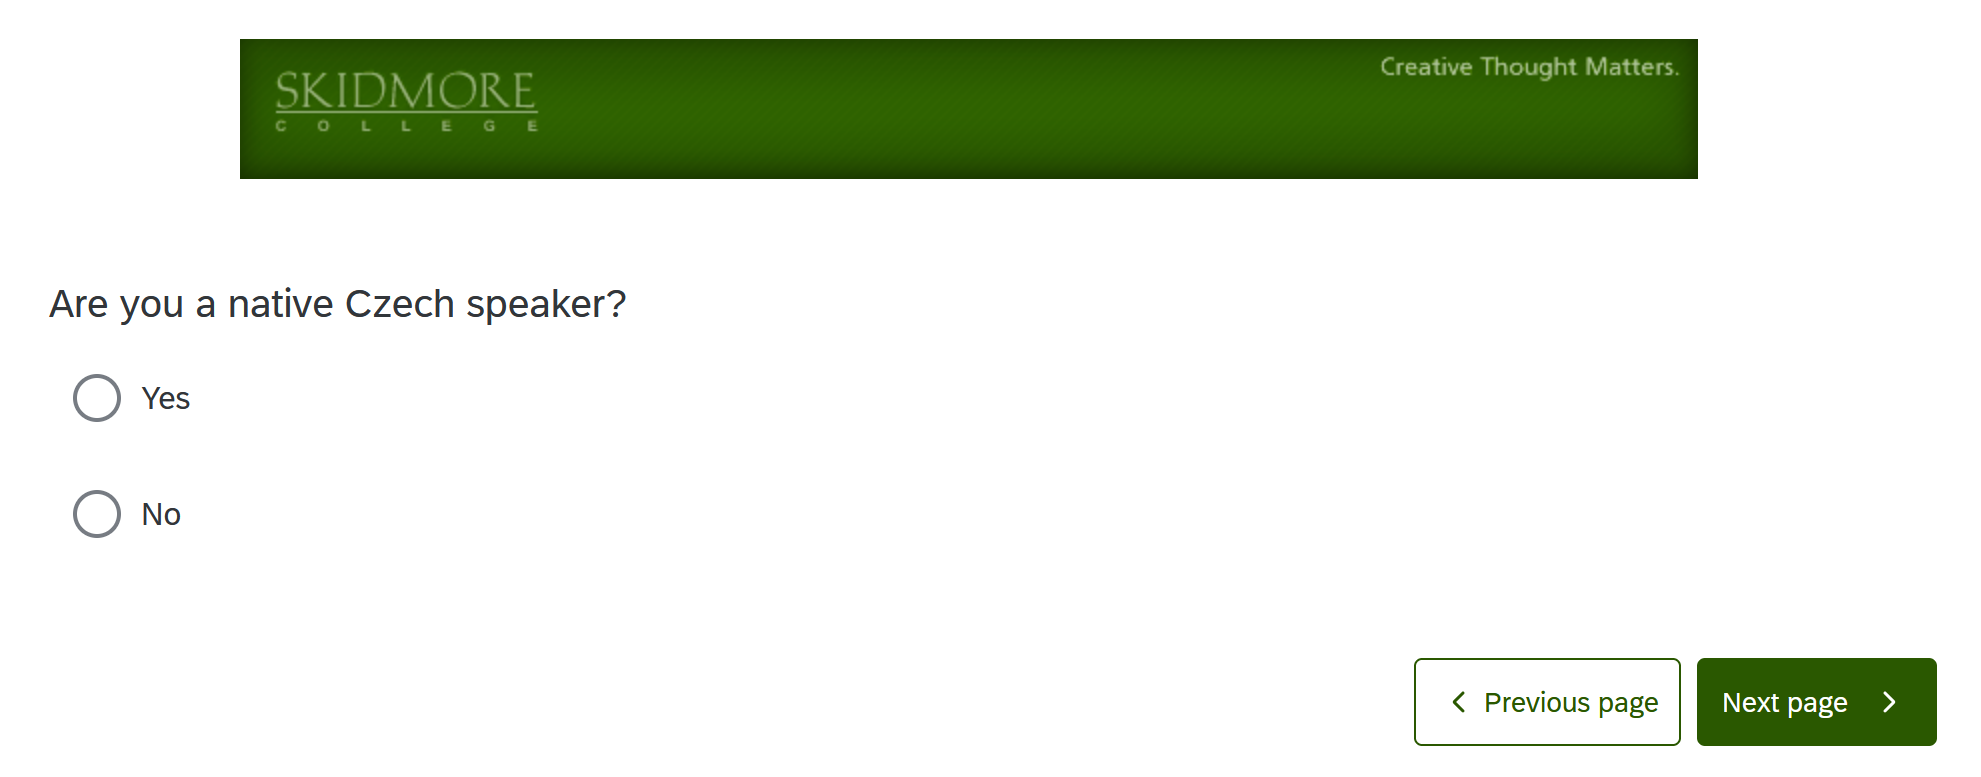

Then, the questions asking to rate the softness of each phoneme is measured on a scale 0 - 100. The audio consisted of my pronounciation of the corresponding consonant phoneme grouped with a vowel. These questions were presented in a random order.

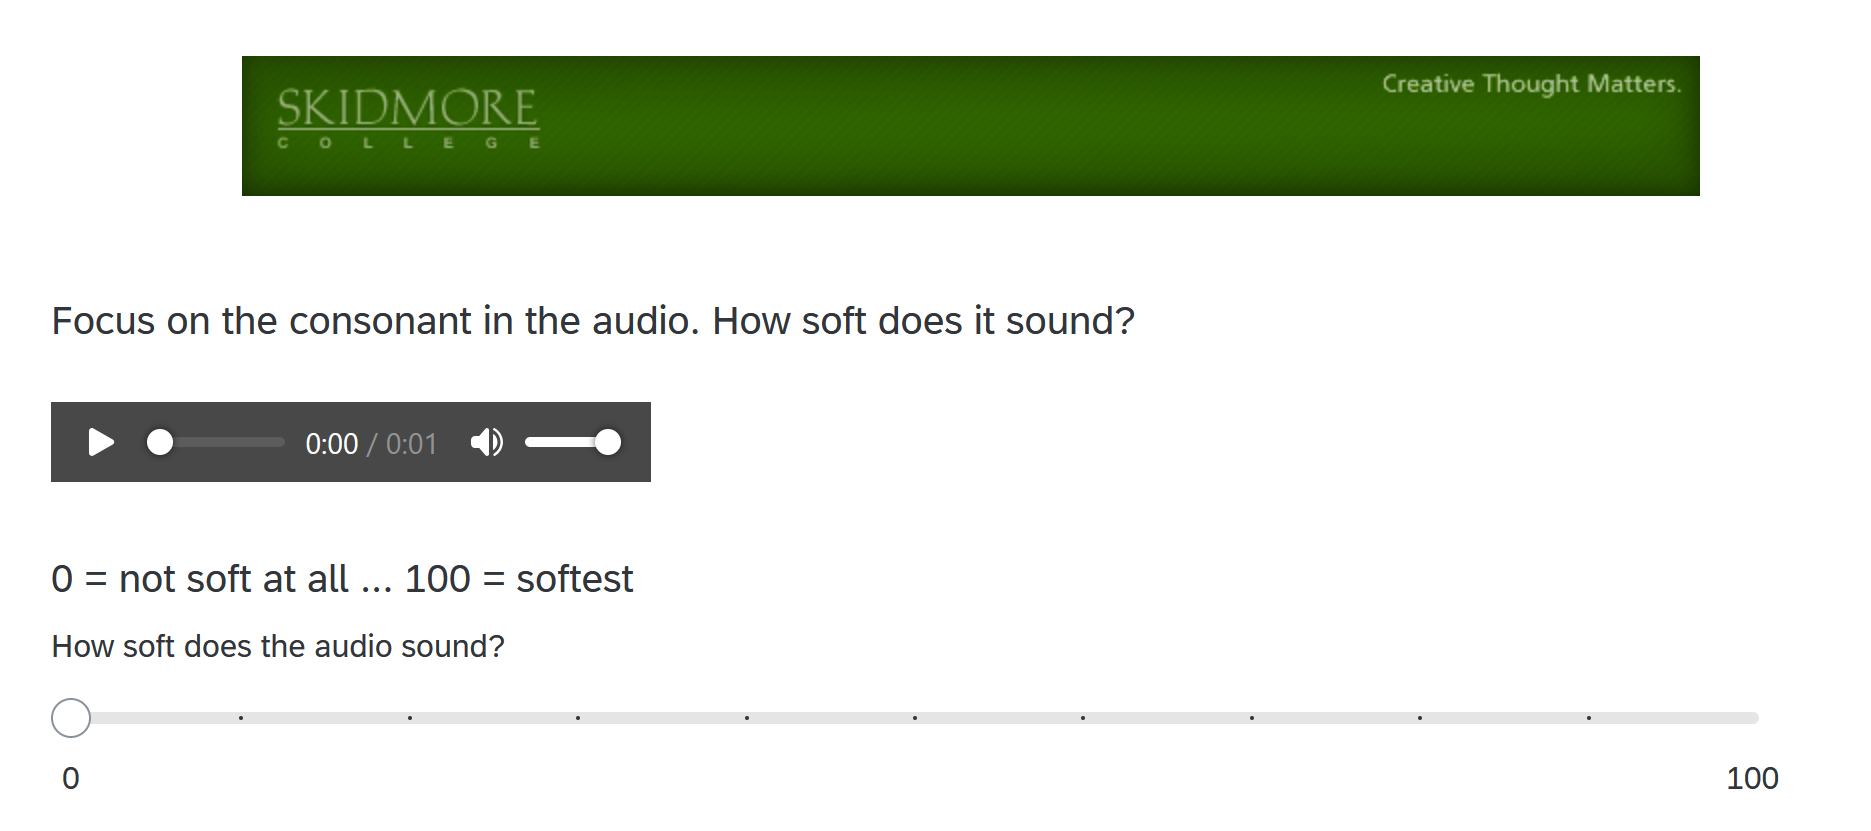

The multiple limitations of the survey design are described in the final report.

### Description of the Survey Data


**D1**: Answer to the question: "Are you a native Czech speaker?" Answers: 1 = yes, 0 = no

Questions **A1_1 - A28_1** are answers to the following question: "Focus on the consonant in the audio. How soft does it sound?  0 = not soft at all ... 100 = softest". Each question was accompanied by an audio of the phoneme. Answers to the questions are a number between 1 and 100.

The dictionnary of question numbers and corresponding tested phonemes:

A1_1: p

A2_1: b

A3_1: t

A4_1: d

A5_1: ť

A6_1: ď

A7_1: k

A8_1: f

A9_1: v

A10_1: s

A11_1: z

A12_1: š

A13_1: ž

A14_1: ks /excluded from analysis, because it consists of two phonemes

A15_1: c

A16_1: č

A17_1: ʣ

A18_1: ʤ

A19_1: m

A20_1: n

A21_1: ň

A22_1: j

A23_1: r

A24_1: l

A25_1: ř

A26_1: ř̥

A27_1: h

A28_1: x

In [ ]:
pre_processed_survey.head()

,D1,A1_1,A2_1,A3_1,A4_1,A5_1,A6_1,A7_1,A8_1,A9_1,...,A19_1,A20_1,A21_1,A22_1,A23_1,A24_1,A25_1,A26_1,A27_1,A28_1
3,0,53,14,48,0,45,20,38,50,14,...,87,87,80,75,68,77,<NA>,19,61,77
4,0,87,69,63,33,52,43,40,83,37,...,61,63,22,38,71,70,65,86,95,95
5,1,11,5,3,72,71,94,5,38,46,...,57,39,100,83,24,61,82,68,16,7
6,0,96,37,19,20,18,15,15,58,11,...,91,54,69,73,75,87,21,52,84,43
7,1,60,70,60,30,80,40,60,70,50,...,80,80,40,80,30,<NA>,30,20,60,<NA>


In [ ]:
pre_processed_survey.compute().describe()

,D1,A1_1,A2_1,A3_1,A4_1,A5_1,A6_1,A7_1,A8_1,A9_1,...,A19_1,A20_1,A21_1,A22_1,A23_1,A24_1,A25_1,A26_1,A27_1,A28_1
count,18.0,18.0,18.0,18.0,18.0,18.0,18.0,18.0,18.0,18.0,...,18.0,18.0,18.0,18.0,17.0,17.0,17.0,18.0,17.0,16.0
mean,0.5,59.444444,48.333333,38.0,31.611111,58.666667,56.666667,25.944444,54.333333,38.611111,...,62.5,56.611111,73.611111,65.611111,41.647059,70.176471,40.764706,36.944444,59.294118,60.6875
std,0.514496,21.060759,22.826713,22.720812,23.958638,29.617165,28.998986,18.357471,25.472015,20.968152,...,24.483488,24.132329,20.719808,20.765183,24.132295,24.385537,27.99895,25.077462,21.612394,29.921495
min,0.0,11.0,5.0,3.0,0.0,14.0,15.0,5.0,6.0,11.0,...,13.0,11.0,22.0,23.0,8.0,5.0,3.0,4.0,16.0,7.0
25%,0.0,50.75,37.75,20.5,16.25,33.75,32.5,14.0,35.0,20.25,...,50.5,38.25,63.0,50.0,14.0,66.0,20.0,16.0,49.0,41.25
50%,0.5,61.5,55.0,36.0,30.0,56.0,55.0,19.0,51.0,40.0,...,66.5,52.0,75.5,71.5,50.0,73.0,34.0,32.0,61.0,69.0
75%,1.0,70.0,67.25,58.0,47.0,83.75,82.75,39.5,77.5,50.0,...,80.0,77.5,87.5,80.0,62.0,83.0,61.0,58.0,72.0,81.25
max,1.0,96.0,80.0,76.0,76.0,100.0,100.0,69.0,100.0,92.0,...,100.0,100.0,100.0,100.0,75.0,100.0,96.0,86.0,95.0,100.0


In [ ]:
consonant_phonemes = ["p","b","t","d","ť","ď","k","f","v","s","z","š","ž","c","č","ʣ","ʤ","m","n","ň","j","r","l","ř","ř̥","h","x"] # Microsoft Copilot was used to generate the following list and was checked for accuracy

In [ ]:
# sorts a dictionnary by values in descending order
def dict_by_val_desc(d):
  return dict(sorted(d.items(), key=lambda item: item[1], reverse=True))

# generates a report on how each consonant was rated on softness
def data_report():
  survey = pre_processed_survey.compute()
  counter = 0
  results_dict = {}
  for col in survey.loc[:, 'A1_1':'A28_1'].columns:
    results_dict[consonant_phonemes[counter]] = survey[col].mean()
    counter += 1

  return dict_by_val_desc(results_dict)

Generate a report of the results of the survey (each phoneme with its corresponding mean softness rating)

In [ ]:
report = data_report()
for key, value in report.items():
  print(key, value)

ň 73.61111111111111
,l 70.17647058823529
,j 65.61111111111111
,m 62.5
,x 60.6875
,p 59.44444444444444
,h 59.294117647058826
,š 58.77777777777778
,ť 58.666666666666664
,ď 56.666666666666664
,n 56.611111111111114
,f 54.333333333333336
,s 48.35294117647059
,b 48.333333333333336
,č 48.0
,ž 46.388888888888886
,r 41.64705882352941
,ř 40.76470588235294
,v 38.611111111111114
,ʣ 38.5625
,t 38.0
,ř̥ 36.94444444444444
,c 36.11764705882353
,ʤ 31.72222222222222
,d 31.61111111111111
,z 31.27777777777778
,k 25.944444444444443


# Conversion to Phonemes

In the Czech language, consonants are mostly pronounced the same way they are written. However, some of them change their voicing depending on the neighboring consonants. The consonants are divided into the following categories:

**Paired voiced consonants**: b, d, ď, g, h, v, w, z, ž, ʣ, ʤ

**Paired voiceless consonants**: p, t, ť, k, ch, f, s, š, c, č

**Sonorant consonants**: j, l, r, m, n, ň

These are the most general rules that characterise gramatically correct pronunciation:

**Paired:**
1.   At the end of the word when not immediately followed by another word,  (implemented only for ending of sentence) the consonant is always voiceless
2.   If the last consonant of a consonant group is voiced, all the consonants in the group are voiced
3.   If the last consonant of a consonant group is voiceless, all the consonants in the group are voiceless

**Sonorant:**
1.   In the middle of a word does not change preceding consonants
2.   When the preceding consonant is the last consonant of a one-syllable preposition, the consonant is voiced
3.   In all other cases the last consonant of the preceding word is voiceless

**Exceptions:**
1.   The consonant 'v' behaves like a paired voiced consonant that influences other paired consonants only in the beginning of words. It can be influenced like a regular paired voiced consonant by other consonants. It does not have the capability to change the voicing of other consonants in the middle of words.

2.   When ř has an immediate neighbor voiceless consonant, it becomes voiceless ř̥. In other cases it is voiced.

**Note:**
More exceptions exist in the czech language, however their implementation would require excessively complex solution that would be beyond the scope of the project. The general rules were implemented and the most prominent exceptions as well. Other exceptions are much less frequent and should not significantly skew the data.


based on https://prirucka.ujc.cas.cz/?id=908

## Utility Functions

In [ ]:
# dictionnary of consonant phonemes from voiced to voiceless and vice versa, x will is the phoneme for ch
v_to_vless_dict = {'b': 'p', 'd':'t', 'ď':'ť', 'g':'k', 'h':'x', 'v':'f', 'w':'f', 'z':'s', 'ž':'š', 'ʣ': 'c', 'ʤ': 'č', 'ř':'ř̥'}
vless_to_v_dict = {'p': 'b', 't':'d', 'ť':'ď', 'k':'g', 'x':'h', 'f':'v', 's':'z', 'š':'ž', 'c': 'ʣ', 'č': 'ʤ' }
sonorant_list = ['j', 'l', 'r', 'm', 'n', 'ň']

# prepositions in the Czech language
all_prepositions = ['à', 'ad', 'během', 'bez', 'beze', 'blízko', 'cestou', 'dík', 'díky', 'dle', 'do', 'jménem', 'k', 'ke', 'kol', 'kolem', 'krom', 'kromě', 'ku', 'kvůli', 'mezi', 'mimo', 'místo', 'na', 'na úkor', 'nad', 'nade', 'namísto', 'napříč', 'naproti', 'narozdíl', 'navrch', 'navzdory', 'nedaleko', 'nevyjímaje', 'o', 'ob', 'od', 'ode', 'ohledně', 'okolo', 'oproti', 'po', 'poblíž', 'pod', 'pode', 'podél', 'podle', 'podlevá', 'podlivá', 'pomocí', 'před', 'přede', 'přes', 'přese', 'při', 'pro', 'prostřednictvím', 'proti', 's', 'se', 'skrz', 'stran', 'stranou', 'u', 'u příležitosti', 'uprostřed', 'v', 'včetně', 've', 'vedle', 'vepředu', 'versus', 'via', 'vinou', 'vis-à-vis', 'vlivem', 'vně', 'vo', 'vod', 'vpředu', 'vstříc', 'vůči', 'vůkol', 'vz', 'vzdor', 'vzhledem k', 'z', 'za', 'ze', 'zkraje', 'zpod', 'zpoza']
one_syllable_prepositions = ['à', 'ad', 'bez','dík', 'dle', 'do', 'k', 'ke', 'kol', 'krom', 'ku','na', 'nad', 'o', 'ob', 'od', 'po', 'pod', 'před', 'přes', 'při', 'pro', 's', 'se', 'skrz', 'stran', 'u', 'v', 've', 'vně', 'vo', 'vod', 'vz', 'vzdor', 'z', 'za', 'ze', 'zpod']

# takes a group of consonants and ensures that their voice matches the last consonant of the group
def voice_group(group: str) -> str:
    replacement = ''

    # if the consonant group ends with a voiced consonant + handling 'v' exception
    if (group[-1] in v_to_vless_dict and group[-1] != 'v' and group[-1] != 'ř') or (group[-1] == 'v' and len(group) > 1 and group[-2] == ' ') or (group[-1] == 'ř' and len(group) > 1 and group[-2] == ' '):

      # each paired voiceless consonant is replaced with its voiced version
      for char in group:
        if char in vless_to_v_dict :
          replacement = replacement + vless_to_v_dict[char]
        else:
          replacement = replacement + char

    # if the consonant group ends with a voiceless consonant
    elif group[-1] in vless_to_v_dict:

      # each paired voiced consonant is replaced with its voiceless version
      for char in group:
        if char in v_to_vless_dict:
          replacement = replacement + v_to_vless_dict[char]
        else:
          replacement = replacement + char

    else:
      replacement = group

    return replacement

# finds consonant groups and ensures all consonants match the appropriate voice of each group
def match_voice_paired(sentence: str) -> str:
  matches = re.finditer('[bcčdďhjklmnňpqrřsštťvwxzž\\s]+', sentence)

  # new variable for the purposes of correct iteration
  new_sentence = sentence

  for m in matches:
    # span of the consonant group
    span = m.span()
    voiced_group = voice_group(sentence[span[0]:span[1]])

    # new sentence is glued together with the updated group of consonants
    new_sentence = new_sentence[:span[0]] + voiced_group + new_sentence[span[1]:]

  return new_sentence

# makes the last phoneme in each sentence voiceless
def voiceless_last(sentence: str) -> str:
  if sentence[-1] in v_to_vless_dict:
    sentence = sentence[:-1] + v_to_vless_dict[sentence[-1]]

  return sentence

def match_voice_son(sentence: str) -> str:
  words = sentence.split()

  for i in range(1, len(words)):
    # if the first consonant of a word is sonorant
    if words[i][0] in sonorant_list:
      # look if the previous word is a one syllable preposition
      if words[i-1] in one_syllable_prepositions:
        # change the last consonant to voiced
        if words[i-1][-1] in vless_to_v_dict:
          words[i-1] = words[i-1][:-1] + vless_to_v_dict[words[i-1][-1]]

      else:
        if words[i-1][-1] in v_to_vless_dict:
          words[i-1] = words[i-1][:-1] + v_to_vless_dict[words[i-1][-1]]

  return ' '.join(words)

# handles the converstion of ř to ř̥ in appropriate cases
def voiceless_rr(sentence: str) -> str:
  letters = list(sentence)

  # checks if any ř has a neighboring voiceless consonant
  for i in range(len(letters)):
    if (letters[i] == 'ř' and i != 0 and letters[i-1] in vless_to_v_dict) or (letters[i] == 'ř' and i != len(letters) - 1 and letters[i+1] in vless_to_v_dict):
      letters[i] = 'ř̥'

  return ''.join(letters)

# a pipeline to ensure proper voice assimilation of each consonant
def voicing_assimilation(sentence: str):
  sentence = voiceless_last(sentence)
  sentence = voiceless_rr(sentence)
  sentence = match_voice_son(sentence)
  sentence = match_voice_paired(sentence)

  return sentence

# expands syllables where either ě or i softens the previous consonant
def expand_soft(sentence: str) -> str:
  softening_expansions = {'bě':'bje', 'di': 'ďi', 'dí': 'ďí', 'dě': 'ďe', 'mě':'mňe', 'ni':'ňi', 'ní':'ňí', 'ně':'ňe', 'pě':'pje', 'ti':'ťi', 'tí':'ťí','tě':'ťe', 'vě':'vje'}

  for key in softening_expansions:
    sentence = sentence.replace(key, softening_expansions[key])

  return sentence

# a pipeline that converts written sentence to its phonological form
def to_phonemes(sentence: str) -> str:
  sentence = sentence.replace('w', 'v').replace('x', 'ks').replace('dz', 'ʣ').replace('dž', 'ʤ').replace('ch', 'x') # direct conversion of consonants to phonemes
  sentence = expand_soft(sentence)
  sentence = sentence.replace('y', 'i').replace('ý', 'í') # both i and y are pronounced the same in Czech, however, i sometimes softens previous consonants and therefore the operation must be performed after expand_soft
  sentence = voicing_assimilation(sentence)


  return sentence



### Tests

Tests were created to capture most of the previously described rules and also cover a variety of combinations and edge cases

In [ ]:
# TEST EXPAND_SOFT
# expansion of several words using expand_soft
assert expand_soft('běhá spěchá vyniká tiše') == 'bjehá spjechá vyňiká ťiše'

# TEST VOICELESS_LAST
# correctly softens only the last consonant of a sentence
assert voiceless_last('lev lev') == 'lev lef'
# does not change anything when vowel is last
assert voiceless_last('lev hledá') == 'lev hledá'

# TEST MATCH_VOICE_SON
# one syllable preposition + sonorant first consonant
assert match_voice_son('přes rok') == 'přez rok'
# one syllable preposition + non-sonorant first consonant
assert match_voice_son('přes týden') == 'přes týden'
# one syllable word (but not preposition) + sonorant
assert match_voice_son('dnes rok') == 'dnes rok'
# word with voiced last consonant followed by a word starting with first consonant sonorant
assert match_voice_son('nejez mou kaši') == 'nejes mou kaši'

# TEST VOICE_GROUP
# voiceless to voiced
assert voice_group('skd') == 'zgd'
# voiced to voiceless
assert voice_group('zgt') == 'skt'

# TEST MATCH_VOICE_PAIRED
# word boundaries
assert match_voice_paired('zákaz vstupu') == 'zákas fstupu'
# in the middle of words
assert match_voice_paired('zakdákat') == 'zagdákat'

# TEST VOICELESS_RR
# voiceless consonant infront ř
assert voiceless_rr('třeba') == 'tř̥eba'
# voiceless consonant before ř in a separate word
assert voiceless_rr('s řekou') == 's řekou'
# voiceless consonant after ř
assert voiceless_rr('řknout') == 'ř̥knout'

# TEST VOICING ASSIMILATION
# general regular cases
assert voicing_assimilation('zákaz vstupu křikl lev') == 'zákas fstupu kř̥ikl lef'
# v can be influenced by its consonant group
assert voicing_assimilation('lávka') == 'láfka'
# v acts like paired when in the beginning of word
assert voicing_assimilation('les vysoký') == 'lez vysoký'
# v acts like sonorant when last in consonant group, but in the middle of a word
assert voicing_assimilation('kvést') == 'kvést'
# v can be first in a sentence
assert voicing_assimilation('vést') == 'vést'

# TEST THE ENTIRE TO_PHONEMES FUNCTION
assert to_phonemes('běhá spěchá vyniká tiše řve řkne') == 'bjehá spjexá viňiká ťiše řve ř̥kne'


## Resolving Performance issues

At this stage, when I wanted to compute even a filtered version of the pre_processed text, even after 10 minutes elapsed, the result was not calculated. I took the following steps to address the issue:

Monitored the computation with


```
with ProgressBar():
```
This allowed me to see that the computation was taking very slowly and progressed around 4 percent in the 10 minutes.

First I suspected, that the heavy use of regular expressions was at fault, so I tried to see how much time it takes to calculate even just the pre_processed text. This alone took a lot of time and so I decided to focus on that step as the main issue.

I suspected that the pdfium might have been at fault, since it loaded page by page and had to extract text from each one. However, when testing several of the books, the extracted text was output virtually instantaneously, so I disregarded pdfium as the source of the issue.

I looked at the ways in which dask performance can be monitored and followed the documentation to enable Dask Distributed and the dashboard using the following code:


```
from dask.distributed import LocalCluster
cluster = LocalCluster()cluster
client = cluster.get_client()
```

There were issues with previewing the dasboard in Colab, so I run it locally on my machine. Upon inspecting the generated graph, I found out that was very complex.

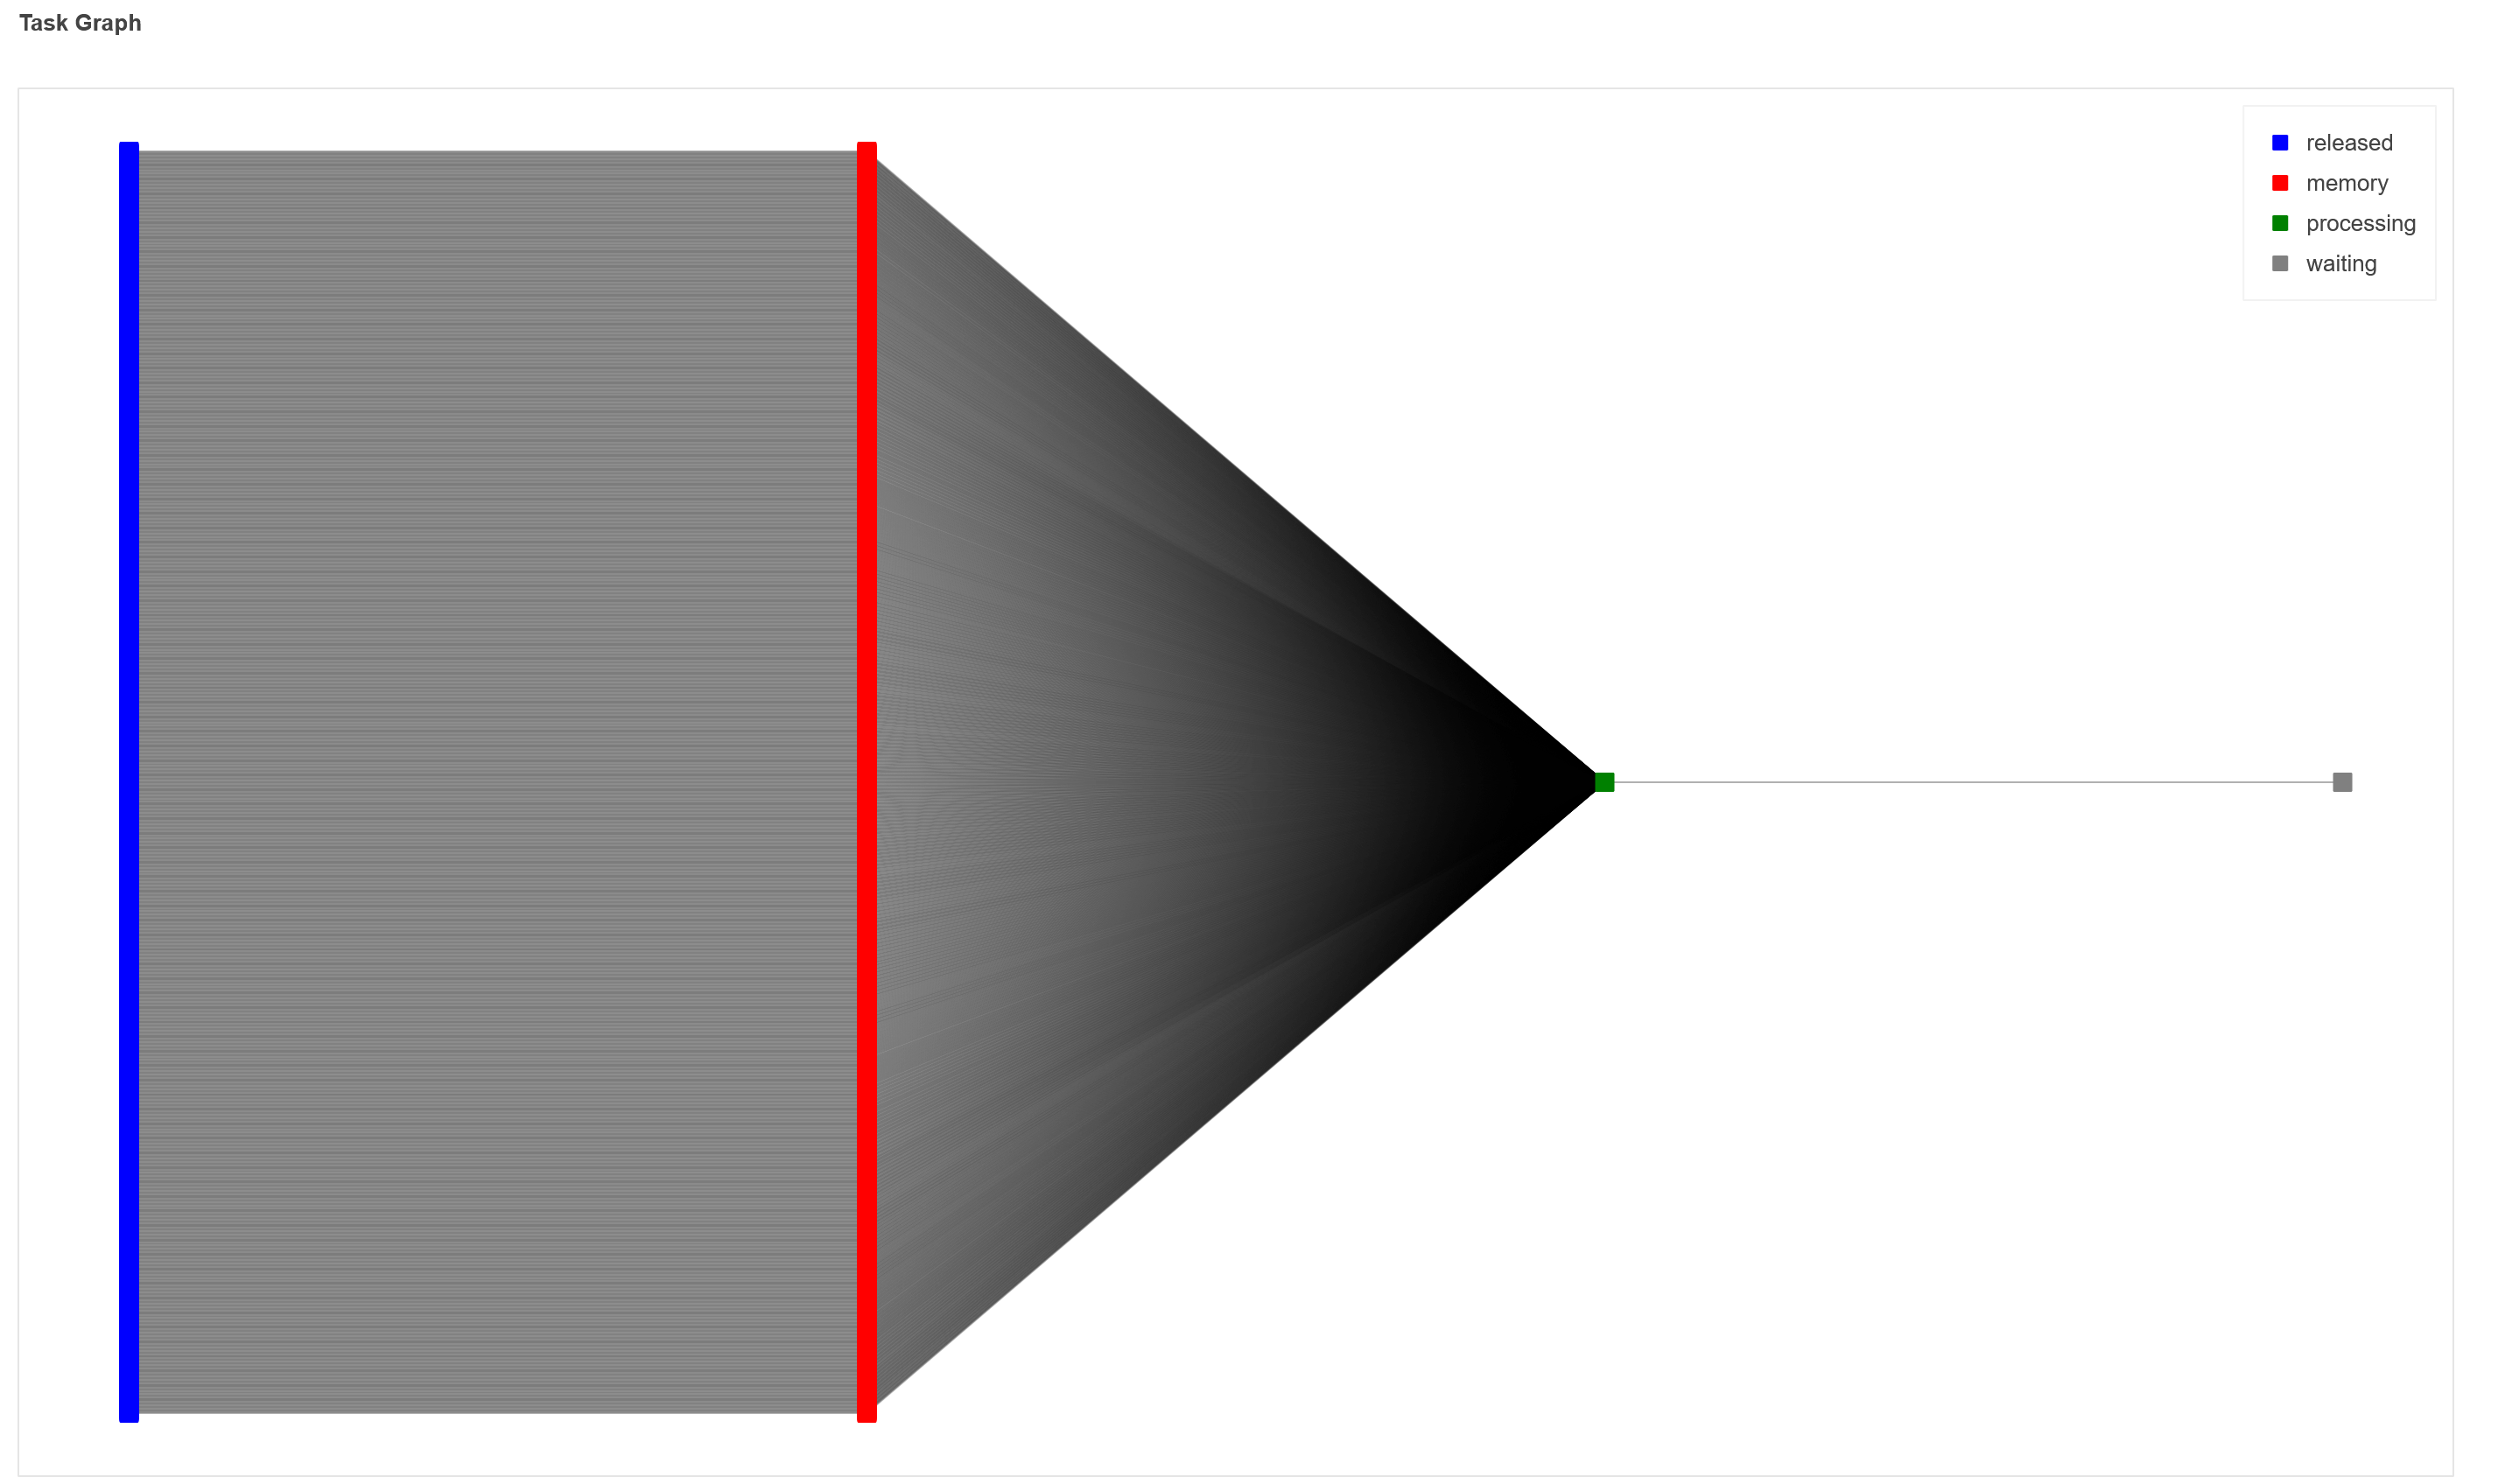

Upon reviewing Dask documentation and recommendations for performance troubleshooting further, I found out, that each partition should be ideally around 100MB in size. My Wikipedia bag of size around 1GB, however, was split in more than 1300 partitions. **I started to implement the repartition function to ensure that my bag has a reasonable number of partitions.**

Thanks to do this, I was able to bring down the time to compute the entire pre_processed dataset down to 10 minutes on my local machine.

However, problems with loading the pdf files in the distributed cluster arised, so I moved back to google colab and decided to keep using the somewhat less informative progress bar.

The computation was progressing much faster, however, at the end, around 97% of the bar progress, the computation stopped and did not move forward. Even though 97% took around 1 minute, the other 3 percent still took around 10 more minutes.

I then tried computing just the books and wikipedia separately. With the books, there were no issues and they could load reasonably quickly in parallel and the progress line was progressing very linearly. Wikipedia on the other hand, even when sampled to a tenth of its original size, displayed the precise pattern of progressing reasonably fast and then stopping at 97% for another 8 minutes.

I was then able to narrow down the bottleneck to the initial loading of th files into the bag using read_text. I tried using various methods, such as loading just file names and mapping the files onto the names manually. This worked only until I wanted to flatten the files so that each line could be one item in the bag. I used Github Copilot (GPT 5.2) to ask about why having many items in a bag is a problem, and I got the answer, that having many objects simply creates overhead and calculating the graph for millions of sentences might be more expensive than their actual processing.

Having identified the issue, if I wanted to analyse the whole Wikipedia, I would let bigger blocks of text be the items in the bag and I would analyze them in serial to produce aggregate values for each block. However, since I had already built all the functions around modifying and analyzing sentences, and because the goal is not to analyze the entire Wikipedia, I decided that I will use **random sampling to obtain a body of text that will represent Wikipedia** without producing millions of sentences.

## Conversion

In [ ]:
all_text_phonemes = pre_processed_text.map(lambda x: (x[0], to_phonemes(x[1])))

In [ ]:
all_text_phonemes.take(3)

(('wiki', 'vlajka marzhallovíx ostrovů'),
 ('wiki',
  'vlajka marzhallovíx ostrovů je tvořena tmavje modrím listem o pomňeru stran původňe podle vlajki usa se dvjema kosími vjejířoviťe se rosšiřujícími pruhi smňeřujícími z dolňího rohu do horňího cípu viz veksilologické názvosloví'),
 ('wiki', 'horňí trojúhelňík je oranžoví dolňí je bílí'))

# Measuring softeness

To measure the softness, the dot product is used, where one matrix represents the results of the survey (i.e. the mean softness ratings for each consonant phoneme), and the frequency of each phoneme in a given word. More explicitely, the softness is defined as the mean softness of each phoneme in the word, where vowels are assumed to have softness 1.

In the softness functions, I use np array to create a dot product. Originally, to demonstrate the full capability of Dask for this project, I used Dask Arrays instead of numpy arrays. The process of obtaining the measurements for the entire body of text was not done even after 12 minutes. I decided to try to use a simple np array to reduce overhead. With using just the simple np array, the measures for the entire body of text could be calculated within seconds! Since my arrays are small, there was not much benefit in parallelism and the associated overhead was too severe. While parallelism is powerful, there are cases when it is best avoided.

## Utility Functions

In [ ]:
# generates a matrix of means for each of the questions A1 - A28. Also gives the opportunity to use responses by Czech native speakers only.
def generate_matrix_of_means(survey: ddf, only_czech: bool = False) -> da:

  if only_czech:
    survey = survey[survey.D1 == 1]

  data = survey.loc[:, 'A1_1':'A28_1']
  means = data.mean()
  array = np.array(means.compute().to_list())

  return array/100

# the normalised matrix of means of user ratings of each consonant phoneme
ratings_matrix = generate_matrix_of_means(pre_processed_survey)

vowels = ['a', 'á', 'e', 'é', 'i', 'í', 'o', 'ó', 'u', 'ú', 'ů', 'y', 'ý'] # the list was generated by Microsoft Copilot and checked for accuracy

# returns the number of vowels
def n_vowels(word: str) -> int:

  v_count = 0

  # counts the vowels
  for ch in word:
    if ch in vowels:
      v_count += 1

  # returns the proportion of vowels
  return v_count

# converts a word to a dask array (for the purpose of evaluating my research question, this is unnecessary, and regular numpy array would suffice, however, it demonstrates the use of a dask array for the purposes of the project)
def word_array(word: str):
  word_arr = np.zeros(27)
  char_num_dict = {}

  # creates a dictionnary of phonemes to position for easy lookup
  for i in range(27):
    char_num_dict[consonant_phonemes[i]] = i

  for ch in word:
    if ch in char_num_dict:
      word_arr[char_num_dict[ch]] += 1

  return word_arr

def sentence_to_softness(item: tuple) -> tuple[str, float, float, float]:
  name = item[0]
  text = item[1].split()

  last = text[-1]
  second_to_last = text[-2]
  rest = ''.join(text[:-1])

  last_softness = softness(last)
  second_to_last_softness = softness(second_to_last)
  rest_softness = softness(rest)

  return (name, last_softness, second_to_last_softness, rest_softness)

def softness(word: str) -> float:
  # vowels are assumed to have softness 1, and the mean softness of each phoneme is the resulting softness
  softness = (np.dot(word_array(word), ratings_matrix) + n_vowels(word))/len(word)
  return softness

def flatten_multilevel(df):
  flat = df.columns = ["_".join(v) for v in df.columns.values]

  return flat


In [ ]:
assert n_vowels('vést') == 1
assert n_vowels('v') == 0
assert n_vowels('aaa') == 3

## Measurement

In [ ]:
all_text_measures = all_text_phonemes.map(lambda x: sentence_to_softness(x))

### Persisting measurement

Pdfium can sometimes have difficulties with parallel processing due to its low level implementation. This could be one of the reasons why when trying to convert to a dask dataframe without intermediary computation, pdfium throws errors. Persist has been used to prevent the errors.

The following step usually takes 70 seconds for the 20MB wikipedia sample to be processed and under 10 minutes for the 100MB sample:

In [ ]:
with ProgressBar():
   measures_persisted = all_text_measures.persist()

[########################################] | 100% Completed | 106.29 s


# Analysis

Standard deviation pooled is calculated based on this article:

Thalheimer, W., & Cook, S. (2002, August). How to calculate effect sizes from published
research articles: A simplified methodology.
http://work-learning.com/effect_sizes.htm.

## Utility Functions

In [ ]:
# only the picked book keeps its name, the rest of the books is put into the 'other' group
def pick_source(source: str, df):

  df.loc[((df['source'] != source) & (df['source'] != 'wiki')), 'source'] = 'other'
  df.loc[df['source'] == source, 'source'] = 'book'

  return df

# generates t-tests to examine the significance between two columns of data for the same group
def gen_t_tests(col1: str, col2: str ,ddf):
  t_tests = babicka.compute().groupby('source')[[col1, col2]].apply(lambda df: (stats.ttest_ind(df[col1], df[col2])[0], stats.ttest_ind(df[col1], df[col2])[1], stats.ttest_ind(df[col1], df[col2]).df)).to_frame(name='results')

  t_tests['t'] = t_tests['results'].apply(lambda x: x[0])
  t_tests['p'] = t_tests['results'].apply(lambda x: x[1])
  t_tests['df'] = t_tests['results'].apply(lambda x: x[2])

  t_tests = t_tests[['t', 'p', 'df']]

  return t_tests

# generates t-tests to examine the significance of relative measures between groups
def gen_between_groups_t_tests(ddf, groups: list[str, str]):
  df = ddf.compute()

  # calculate the mean differences
  group1_l_stl_md = df.loc[groups[0]]['l_stl_delta']
  group2_l_stl_md = df.loc[groups[1]]['l_stl_delta']

  group1_l_rest_md = df.loc[groups[0]]['l_rest_delta']
  group2_l_rest_md = df.loc[groups[1]]['l_rest_delta']

  # counts of datapoints in each group
  group1_n = int(df.loc[groups[0]]['last_count'])
  group2_n = int(df.loc[groups[1]]['last_count'])

  # calculate the pooled standard deviations
  group1_l_stl_std_pooled = s_pooled(df.loc[groups[0]]['last_std'], group1_n, df.loc[groups[0]]['second_to_last_std'], group1_n)
  group2_l_stl_std_pooled = s_pooled(df.loc[groups[1]]['last_std'], group2_n, df.loc[groups[1]]['second_to_last_std'], group2_n)

  group1_l_rest_std_pooled = s_pooled(df.loc[groups[0]]['last_std'], group1_n, df.loc[groups[0]]['rest_std'], group1_n)
  group2_l_rest_std_pooled = s_pooled(df.loc[groups[1]]['last_std'], group2_n, df.loc[groups[1]]['rest_std'], group2_n)

  # calculate the t-tests
  l_stl_t_test = stats.ttest_ind_from_stats(mean1=group1_l_stl_md,
                                            std1=group1_l_stl_std_pooled,
                                            nobs1=group1_n,
                                            mean2=group2_l_stl_md,
                                            std2=group2_l_stl_std_pooled,
                                            nobs2=group2_n)

  l_rest_t_test = stats.ttest_ind_from_stats(mean1=group1_l_rest_md,
                                            std1=group1_l_rest_std_pooled,
                                            nobs1=group1_n,
                                            mean2=group2_l_rest_md,
                                            std2=group2_l_rest_std_pooled,
                                            nobs2=group2_n)

  resultsummary = ('Between groups t-tests for ' + groups[0] + ' and ' + groups[1] + ':\n' +
                   '\tDifference in (softness of last - softness of second to last word): \n' +
                   '\t\t t =' + str(float(l_stl_t_test[0])) + '\n' +
                   '\t\t p =' + str(float(l_stl_t_test[1])) + '\n' +
                   '\t___________\n' +
                   '\tDifference in (softness of last - softness of the rest of sentence): \n' +
                   '\t\t t =' + str(float(l_rest_t_test[0])) + '\n' +
                   '\t\t p =' + str(float(l_rest_t_test[1])) + '\n' +
                   '\t___________' )
  return resultsummary

# calculates the pooled standard deviation of two groups of data
def s_pooled(s_t: float, n_t: int, s_c: float, n_c: int) -> float:
  s_pooled = math.sqrt(
      ((n_t - 1)*s_t**2 + (n_c-1)*s_c**2)/(n_t + n_c)
  )

  return s_pooled

## Conversion to Dask Dataframe

At this point, the data is processed and structured enough to be converted to a Dask Dataframe. The conversion will allow for easier operations such as column manipulation or groupby.

In [ ]:
dataset = measures_persisted.to_dataframe(meta=({'source': str, 'last': float, 'second_to_last': float, 'rest': float}))

At this point, the dataset consists of entries where each line represents a sentence. The dataset contains the following columns:

**source**: body of text from which the sentence comes

**last**: softness of the last word

**second_to_last**: softness of the second to last word

**rest**: softness to the rest of the sentence (without last word)

In [ ]:
dataset.head()

,source,last,second_to_last,rest
0,wiki,0.666587,0.695309,0.685952
1,wiki,0.683641,0.653803,0.705644
2,wiki,0.796275,0.828056,0.739005
3,wiki,0.713059,0.708147,0.705920
4,wiki,0.755815,0.000000,0.700754


Since in this research, we are examining specifically the book Babička, we create a dataset specific to babička, by grouping together all other books

## Picking the Babička (*The Grandmother*) book

In [ ]:
babicka = dataset.map_partitions(lambda x: pick_source(source=examined_book, df=x))

## Describing the data

We group the data by source and calculate some basic statistics about the data:

**source**: origin of the body of text. wiki = Wikipedia, book = The Babička book, other = the other books

**last_mean**: mean softness of the last words

**last_std**: standard deviation of the softnesses of the last words

**last_count**: number of last words

**second_to_last_mean**: mean softness of the second to last words

**second_to_last_std**: standard deviation of the softnesses of the second to last words

**second_to_last_count**: number of second to last words

**rest_mean**: mean softness of the sentences when excluding the last word

**rest_std**: standard deviation of the softnesses of the rests of the sentences when excluding the last word

**rest_count**: number of sentences with last word excluded





In [ ]:
data_stats = babicka.groupby('source').agg(['mean', 'std', 'count'])
data_stats.columns = flatten_multilevel(data_stats)
data_stats['l_stl_delta'] = data_stats['last_mean'] - data_stats['second_to_last_mean']
data_stats['l_rest_delta'] = data_stats['last_mean'] - data_stats['rest_mean']

In [ ]:
data_stats.compute()

,last_mean,last_std,last_count,second_to_last_mean,second_to_last_std,second_to_last_count,rest_mean,rest_std,rest_count,l_stl_delta,l_rest_delta
source,,,,,,,,,,,
wiki,0.688074,0.095625,162623,0.693488,0.134636,162623,0.695689,0.028309,162623,-0.005414,-0.007615
book,0.704447,0.069303,4283,0.706275,0.133407,4283,0.705783,0.027733,4283,-0.001828,-0.001336
other,0.696239,0.076700,169131,0.704351,0.131986,169131,0.699699,0.033581,169131,-0.008112,-0.003460


## Calculating the t-test statistics for the Babička book

Do the last words and the second to last words differ significantly in terms of softness?

In [ ]:
gen_t_tests('last', 'second_to_last', babicka)

,t,p,df
source,,,
book,-0.795965,4.260745e-01,8564.0
other,-21.854130,8.409686e-106,338260.0
wiki,-13.220456,6.846369e-40,325244.0


Do the last words and the rest of the sentence differ significantly in terms of softness?

In [ ]:
gen_t_tests('last', 'rest', babicka)

,t,p,df
source,,,
book,-1.171639,2.413746e-01,8564.0
other,-16.995677,9.406363e-65,338260.0
wiki,-30.790553,6.997639e-208,325244.0


In the measures above, we found that while in there are no significant differences for Babička, second to last words and the rest of sentence are significantly less soft than the last word. It is possible that in regular text, last words are less soft than the second to last words or the rest of the sentence and even though Němcová pushes soft words to the end of sentence, they merely counterbalance this general pattern. To examine this possibility we look whether there is a significant difference between the book, other books, and wikipedia in their relative differences in softness.

Is there a significant difference between Babička and the other books in terms of their "softness of last word - softness of second to last word" and "softness of last word - softness of the rest of the sentence"?

In [ ]:
print(gen_between_groups_t_tests(data_stats, groups=('book','other')))

Between groups t-tests for book and other:
,	Difference in (softness of last - softness of second to last word): 
,		 t =3.7637720187979977
,		 p =0.00016742459219625002
,	___________
,	Difference in (softness of last - softness of the rest of sentence): 
,		 t =2.3244022336926404
,		 p =0.02010509484926899
,	___________


Is there a significant difference between Babička and the Wikipedia sample in terms of their "softness of last word - softness of second to last word" and "softness of last word - softness of the rest of the sentence"?

In [ ]:
print(gen_between_groups_t_tests(data_stats, groups=('book','wiki')))

Between groups t-tests for book and wiki:
,	Difference in (softness of last - softness of second to last word): 
,		 t =1.9878898384363763
,		 p =0.04682550585403296
,	___________
,	Difference in (softness of last - softness of the rest of sentence): 
,		 t =5.783968628742151
,		 p =7.308818331188073e-09
,	___________


The t-tests suggest the following:

In the book Babička, there is no significant difference between the last words and second to last words, since p > .5. However, both in the wikipedia and other books bodies of test show that the second to last words and the rest of sentences are significantly more soft than the last word p < .001

As for the relative measures of softness of last word - softness of second to last word, there is a statistically significant difference between the book Babička, and the other books and wikipedia, because for both, p < .001. For the measure of softness of last word - softness of the rest of the sentence, the difference is significant only between the book Babička and the Wikipedia sample (p < .001).


# Exploratory analysis using shingles

## Utility Functions

In [ ]:
# converts a word to 2-shingles. Dictionnary of the shingles with corresponding frequencies is returned together with the total number of shingles in the word
def word_to_2shingles(word: str):
  shingles = {}
  for i in range(1, len(word)):
    shingle = word[i-1] + word[i]

    if shingle in shingles:
      shingles[shingle] = shingles[shingle] + 1
    else:
      shingles[shingle] = 1

  return shingles, len(word) - 1

# effectively performs a merge on two dictionnaries, but if they have any shingles in common, the two values are added
def add_dicts(dict1, dict2):
  total_dict = dict1
  for key in dict2:
    if key in dict1:
      total_dict[key] = dict1[key] + dict2[key]
    else:
      total_dict[key] = dict2[key]

  return total_dict

# subtracts the values of dictionnary 2 from the corresponding values in dictionnary 1
def sub_dicts(dict1, dict2):
  total_dict = dict1
  for key in dict2:
    if key in dict1:
      total_dict[key] = dict1[key] - dict2[key]
    else:
      total_dict[key] = -dict2[key]

  return total_dict

# performs the dict addition on tuples of dictionnaries while also passing the total sums of shingles
def add_dict_tuples(dicts1, dicts2):
  return ((add_dicts(dicts1[0][0], dicts2[0][0]), dicts1[0][1] + dicts2[0][1]) , (add_dicts(dicts1[1][0], dicts2[1][0]), dicts1[1][1] + dicts2[1][1]))

# normalises the dictionnaries by dividing each frequence by the total number of shingles
def normalise_dict(t: tuple[dict, int]):
  d_norm = {}
  for key in t[0]:
    d_norm[key] = t[0][key]/t[1]

  return d_norm

In [ ]:
dict1 = {'a': 3, 'ab': 2, 'cd': 4, 'xy': 0}
dict2 = {'ab': 3, 'cd': 0, 'fg': 0, 'hi': 5}
assert add_dicts(dict1, dict2) == {'a': 3, 'ab': 5, 'cd': 4, 'xy': 0, 'fg': 0, 'hi': 5}

dict1 = {'a': 3, 'ab': 2, 'cd': 4, 'xy': 0}
assert normalise_dict((dict1, 9)) == {'a': 3/9,'ab': 2/9,'cd': 4/9, 'xy': 0/9}

assert word_to_2shingles('ananas') == ({'an': 2, 'na': 2, 'as': 1}, 5)

## Shingling

First, for each sentence, the shingles for the last and second to last word is determined. The number of shingles is also calculated, for later effective parallel addition. The format of each item in the bag is `((shingles last, number of shingles in last), (shingles second to last, number of shingles in second to last))`.

Then, the shingle dictionnaries and numbers of shingles are added together by reducing the data using the `fold()` method.

In [ ]:
with ProgressBar():
  all_text_shingles = all_text_phonemes.map(lambda x: (word_to_2shingles(x[1].split()[-1]), word_to_2shingles(x[1].split()[-2])))
  totals = all_text_shingles.fold(add_dict_tuples).compute()

[########################################] | 100% Completed | 87.38 s


## Calculating Difference

In [ ]:
normalised_dicts = (normalise_dict(totals[0]), normalise_dict(totals[1]))
difference = (sub_dicts(normalised_dicts[0], normalised_dicts[1]))
sorted_diff = dict_by_val_desc(difference)

In [ ]:
more_in_last = dict(list(sorted_diff.items())[:10])
more_in_second_to_last = dict(list(sorted_diff.items())[-10:])

In [ ]:
more_in_last

{'ku': 0.003116067211963074,
 'ra': 0.003107912719805983,
 'vi': 0.0026430418727013284,
 'st': 0.0025471491811112686,
 'ki': 0.0023546346408662606,
 'ka': 0.002237847643264689,
 'ce': 0.0020931575911586732,
 'li': 0.0019899369839179813,
 'os': 0.001807339206358497,
 'ro': 0.0018003104052568067}

In [ ]:
more_in_second_to_last

{'kí': -0.0037847434530709945,
 'éh': -0.004361671737339183,
 'íx': -0.0044008025147823735,
 'na': -0.004464411720298768,
 'je': -0.004779332109607792,
 'ím': -0.004826735011778282,
 'sk': -0.00584046152039361,
 'ňí': -0.006808531159730656,
 'ké': -0.007125644417152812,
 'ho': -0.0076921070023680945}

There are several relevant things to be noted.

1. The shingles that appear more in last compared to the second to last word, are heavy on the consonant phonemes that were rated as less soft in the survey (e.g. 'k', 'c', 'v'). Conversely, the shingles that appear more in the second to last word compared to the last word, are heavier on consonant phonemes that were rated as softer in the survey (e.g. 'h', 'ch', 'j', 'ň'). This is consistent with the previous findings, that in a general text, the second to last words are softer than the last words.

2. A very insightful observation is that the shingles that are more in the second to last words than in the last words, are common suffixes to declined adjectives. This makes sense, since adjectives rarely appear at the end of the sentence in the Czech language. Based on this observation, future analysis could include removal of words that are unlikely to appear at the end of the sentence such as adjectives or prepositions to see how much they skew the results.

# Performance analysis

## Scalability on a Single CPU in Colab

The performance of the entire analysis pipeline ranging from data loading through softness measuring up until the explorative shingling is measured.

The following code assumes, that previous cells in the notebook have been run.

In [ ]:
def measure_perf(wiki_sample: int, books_sample: int):
  start = time.perf_counter()

  # loading the data
  books_names = []
  for i in range(books_sample):
    books_names.append(book_file_names[i])

  books = db.from_sequence(books_names).map(book_loader)
  wiki = (
      db.read_text(generate_wiki_urls(sample_size=wiki_sample))
      .filter(lambda x: x[:4] != '<doc' and '__NOEDITSECTION__' not in x and '</doc>' not in x)
      .map(lambda x: ('wiki', x))
  )

  books = books.repartition(npartitions=2)
  wiki = wiki.repartition(npartitions=int(wiki_sample_size/100) + 1)

  survey_anonymized = ddf.read_csv('DATA301_Project/survey/anonymized_data.csv', na_values=['<NA>'])

  all_text = db.concat([wiki, books])

  # data pre-processing
  expr_to_clean = ['\n', '\r', ',', '-', '–', '—', ';', '“', '0', '1', '2', '3', '4', '5', '6','7','8','9','\x02', '(', ')', '„', '•', '&ltbr', '&gt', '"', '↓', '/', '=']
  pre_processed_text = (
      all_text.map(lambda x: (x[0], clean_text(x[1], expr_to_clean))) # removes specified expressions
      .map(lambda x: (x[0], expand_abbr(x[1]))) # expands abbreviations
      .map(lambda x: (x[0], keep_printable(x[1])))
      .map(lambda x: (x[0], remove_non_ending_stops(x[1]))) # removes sentence ending characters outside the context of a sentence end
      .map(lambda x: to_sentences(x)).flatten() # splits items into sentences
      .map(lambda x: (x[0], x[1].strip())) # strips trailing spaces
      .filter(lambda x: x[1] != '') # excludes empty strings
      .filter(lambda x: len(x[1].split()) >= 3) # excludes sentences that have less than 3 words
      .filter(lambda x: x[1][0].isupper()) # excludes sentences that start with a lowercase character and therefore are likely incomplete
      .filter(lambda x: bool(x) and x != {})
      .map(lambda x: (x[0], x[1].lower()))
  )

  # survey data preprocessing pipeline
  pre_processed_survey = (survey_anonymized.loc[:, 'D1':'A28_1'] # responses to the questions
                          [survey_anonymized['Finished'] == 'True'] # only those participants who have finished the survey
                          [survey_anonymized['DistributionChannel'] == 'anonymous'] # only production distribution of the survey (excludes previews)
                          )
  pre_processed_survey['D1'] = pre_processed_survey['D1'].replace({'Yes': '1', 'No': '0'})
  pre_processed_survey = pre_processed_survey.drop(columns='A14_1')
  pre_processed_survey = pre_processed_survey.map_partitions(df_to_num)

  # conversion to phonemes
  all_text_phonemes = pre_processed_text.map(lambda x: (x[0], to_phonemes(x[1])))

  # measuring softness
  all_text_measures = all_text_phonemes.map(lambda x: sentence_to_softness(x))
  measures_persisted = all_text_measures.persist()

  # analysis
  dataset = measures_persisted.to_dataframe(meta=({'source': str, 'last': float, 'second_to_last': float, 'rest': float}))
  babicka = dataset.map_partitions(lambda x: pick_source(source=examined_book, df=x))

  data_stats = babicka.groupby('source').agg(['mean', 'std', 'count'])
  data_stats.columns = flatten_multilevel(data_stats)
  data_stats['l_stl_delta'] = data_stats['last_mean'] - data_stats['second_to_last_mean']
  data_stats['l_rest_delta'] = data_stats['last_mean'] - data_stats['rest_mean']

  data_stats_computation = data_stats.compute()

  t_tests1 = gen_t_tests('last', 'second_to_last', babicka)
  t_tests2 = gen_t_tests('last', 'rest', babicka)
  t_tests3 = gen_t_tests('last', 'rest', babicka)
  t_tests4 = gen_t_tests('last', 'rest', babicka)

  # exploratory analysis
  all_text_shingles = all_text_phonemes.map(lambda x: (word_to_2shingles(x[1].split()[-1]), word_to_2shingles(x[1].split()[-2])))
  totals = all_text_shingles.fold(add_dict_tuples).compute()

  normalised_dicts = (normalise_dict(totals[0]), normalise_dict(totals[1]))
  difference = (sub_dicts(normalised_dicts[0], normalised_dicts[1]))
  sorted_diff = dict_by_val_desc(difference)

  more_in_last = dict(list(sorted_diff.items())[:10])
  more_in_second_to_last = dict(list(sorted_diff.items())[-10:])

  end = time.perf_counter()

  print('wiki sample size:', wiki_sample, ', book sample size:', books_sample, ', time:', end - start)

  return

In [ ]:
measure_perf(20, 2)
measure_perf(30, 3)
measure_perf(40, 4)
measure_perf(50, 5)
measure_perf(60, 6)
measure_perf(70, 7)
measure_perf(80, 8)
measure_perf(100, 10)
measure_perf(200, 20)
measure_perf(300, 30)

wiki sample size: 20 , book sample size: 2 , time: 189.24426152900014
,wiki sample size: 30 , book sample size: 3 , time: 275.03464867599996
,wiki sample size: 40 , book sample size: 4 , time: 380.51951020799993
,wiki sample size: 50 , book sample size: 5 , time: 500.1058142249999
,wiki sample size: 60 , book sample size: 6 , time: 541.0406756339999
,wiki sample size: 70 , book sample size: 7 , time: 649.543159588
,wiki sample size: 80 , book sample size: 8 , time: 755.230661261
,wiki sample size: 100 , book sample size: 10 , time: 921.083362206
,wiki sample size: 200 , book sample size: 20 , time: 1855.0573097100005
,wiki sample size: 300 , book sample size: 30 , time: 2767.6931406930007


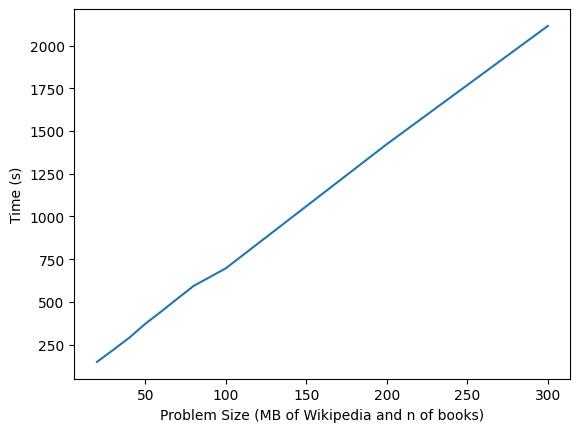

In [ ]:
problem_size = [20, 30, 40, 50, 60, 70, 80, 100, 200, 300]
times = [149.28, 218.87, 290.14, 372.10, 444.8, 519.78, 593.67, 696.72, 1423.22, 2114.86]

fig, ax = plt.subplots()             # Create a figure containing a single Axes.
ax.plot(problem_size, times)  # real data
ax.set_xlabel("Problem Size (MB of Wikipedia and n of books)")
ax.set_ylabel('Time (s)')
plt.show()

In [ ]:
measure_perf(0, 51)

wiki sample size: 0 , book sample size: 51 , time: 12517.588478126


## Weak Scalability

The file for testing weak scalability is virtually identical to the single machine performance test, but with all the necessary utility functions included. Additionally, Dask is run in its distributed client version.

In [ ]:
%%writefile analysis.py

# @title Python File

# imports
import sys
import dask.bag as db
import dask.dataframe as ddf
import dask.array as da
import pandas as pd
import numpy as np
import pypdfium2 as pdfium
import re
import time
import random
import math
from scipy import stats
import os
from dask.distributed import Client, LocalCluster

# global declarations
# ensures reproducibility of results
random.seed(42)

# used later when deciding which book is compared to the other books and wikipedia
examined_book = 'babicka_bozena_nemcova'

# book file names
book_file_names = ['babicka_bozena_nemcova',
'windows8_redakce_businessIT_a_partneri',
'cesky_rozhlas-historie_eva_jesutova_a_kolektiv',
'flvek_05_alois_jirasek',
'flvek_4_alois_jirasek',
'flvek_03_alois_jirasek',
'flvek_02_alois_jirasek',
'flvek_01_alois_jirasek',
'jihoslovanske_jazyky_pavel_krejci',
'nase_nynejsi_krise_tomas_garrigue_masaryk',
'lucerna_alois_jirasek',
'matka_karel_capek',
'basne_josef_vaclav_sladek',
'dalimilova_kronika_dalimil',
'obycejny_zivot_karel_capek',
'povetron_karel_capek',
'hordubal_karel_capek',
'noc_na_karlstejne_jaroslav_vrchlicky',
'pisne_kosmicke_jan_neruda',
'domaci_kucharka_magdalena_dobromila_rettigova',
'hovory_s_tg_masarykem_karel_capek',
'dramaticke_zlomky_karel_hynek_macha',
'povidani_o_pejskovi_a_kocicce_josef_capek',
'obrazy_z_dejin_naroda_ceskeho_iii_vladislav_vancura',
'obrazy_z_dejin_naroda_ceskeho_ii_vladislav_vancura',
'obrazy_z_dejin_naroda_ceskeho_i_vladislav_vancura',
'rur_karel_capek',
'bylo_nas_pet_karel_polacek',
'mistr_kampanus_zikmund_winter',
'konec_starych_casu_vladislav_vancura',
'ballady_a_romance_jan_neruda',
'vec_makropulos_karel_capek',
'krakatit_karel_capek',
'filosofska_historie_alois_jirasek',
'stare_povesti_ceske_alois_jirasek',
'devatero_pohadek_karel_capek',
'kosmuw_letopis_cesky_kosmas',
'tezka_hodina_jiri_wolker',
'host_do_domu_jiri_wolker',
'nova_evropa_tomas_garrigue_masaryk',
'sedm_let_v_jizni_africe_iv_emil_holub',
'sedm_let_v_jizni_africe_iii_emil_holub',
'sedm_let_v_jizni_africe_druha_cesta_emil_holub',
'sedm_let_v_jizni_africe_prvni_cesta_emil_holub',
'bila_nemoc_karel_capek',
'rozmarne_leto_vladislav_vancura',
'maj_karel_hynek_macha',
'kytice_karel_jaromir_erben',
'osudy_dobreho_vojaka_svejka_jaroslav_hasek_volumes3and4',
'osudy_dobreho_vojaka_svejka_jaroslav_hasek_volumes1and2',
'broucci_jan_karafiat',
]

# loads books and converts from pdf to txt
def book_loader(filename: str) -> tuple[str, str]:
  document = pdfium.PdfDocument('DATA301_Project/books/' + filename + '.pdf')

  version_marker_found = 0
  book_started = 0
  text = ''
  for page in document:
    # extract text from the page
    textpage = page.get_textpage()
    extractedtext = textpage.get_text_bounded()

    # the following two conditions ensure that the material attached to the book that is not a part of the original text is skipped (for example the cover page, info about publication etc.)
    if version_marker_found == 0 and 'verze' in extractedtext.lower():
      version_marker_found = 1

    # after the version marker is found (indicating the last page of added material), the next page is checked for containing the contents (obsah) of the book which can also be skipped.
    elif version_marker_found and book_started == 0:
      if 'obsah' not in extractedtext.lower():
        book_started = 1

    if book_started:
      text += extractedtext

  return filename, text

# generates urls for all the wiki files
def generate_wiki_urls(last_chr: str = 'N', last_number: int = 55, sample_size: int = 0) -> list[str]:
  urls = []
  current_chr = 'A'
  current_num_str = '00'

  # generates urls for all the files
  while ord(current_chr) <= ord(last_chr):
    n_of_files = 100

    if ord(current_chr) == ord(last_chr):
      n_of_files = last_number + 1

    for i in range(n_of_files):
      if i < 10:
        current_num_str = '0' + str(i)
      else:
        current_num_str = str(i)

      urls.append('DATA301_Project/wiki/A' + current_chr + '/' + 'wiki_' + current_num_str)

    current_chr = chr(ord(current_chr) + 1)

  if sample_size:
    urls = random.sample(urls, k=sample_size)

  return urls

abbr_dict = {
    "adj.": "adjektivum",
    "adv.": "adverbium",
    "aj.": "a jiné",
    "akuz.": "akuzativ",
    "apod.": "a podobně",
    "atd.": "a tak dále",
    "býv.": "bývalý",
    "č.": "č",
    "čes.": "český",
    "dat.": "dativ",
    "dolož.": "doloženo",
    "doudl.": "doudlebský",
    "dř.": "dříve",
    "f.": "femininum",
    "gen.": "genitiv",
    "imp.": "imperativ",
    "ind.": "indikativ",
    "inf.": "infinitiv",
    "inform.": "informátor",
    "instr.": "instrumentál",
    "jč.": "jihočeský",
    "již.": "jižní",
    "jjv.": "jihojihovýchodní",
    "jjz.": "jihojihozápadní",
    "jv.": "jihovýchod",
    "jz.": "jihozápad",
    "jzč.": "jihozápadočeský",
    "km": "kilometr",
    "kol.": "kolektiv",
    "kond.": "kondicionál",
    "lid.": "lidový",
    "lok.": "lokál",
    "m.": "maskulinum",
    "m n. m.": "metry nad mořem",
    "min.": "minulý",
    "n. l.": "našeho letopočtu",
    "např.": "například",
    "nar.": "narozen",
    "nář.": "nářečí",
    "nepřízv.": "nepřízvučný",
    "neživ.": "neživotný",
    "nom.": "ominativ",
    "obl.": "oblast",
    "obyv.": "obyvatel",
    "okr.": "okres",
    "os.": "osoba",
    "pl.": "plurál",
    "plt.": "plurale tantum",
    "poč.": "počátek",
    "popř.": "popřípadě",
    "préz.": "prézens",
    "protet.": "protetický",
    "předp.": "předpona",
    "přech.": "přechodník",
    "příč.": "příčestí",
    "příp.": "přípona",
    "přísl.": "příslovce",
    "přít.": "přítomný",
    "přivl.": "přivlastňovací",
    "př. n. l.": "před naším letopočtem",
    "pův.": "původní",
    "r.": "rok",
    "s.": "strana",
    "samohl.": "samohláska",
    "sev.": "severní",
    "sg.": "singulár",
    "slez.": "slezský",
    "souhl.": "souhláska",
    "ssv.": "severoseverovýchodní",
    "ssz.": "severoseverozápadní",
    "stol.": "století",
    "střč.": "středočeský",
    "střm.": "středomoravský",
    "subst.": "substantivum",
    "sv.": "svatý",
    "svč.": "severovýchodočeský",
    "sz.": "severozápad",
    "tj.": "to je",
    "trp.": "trpný",
    "tř.": "třída",
    "tzn.": "to znamená",
    "tzv.": "takzvaný",
    "ukaz.": "ukazovací",
    "vjv.": "východojihovýchodní",
    "vm.": "východomoravský",
    "vok.": "vokativ",
    "vsv.": "východoseverovýchodní",
    "vých.": "východní",
    "zájm.": "zájmeno",
    "záp.": "západní",
    "zč.": "západočeský",
    "zjz.": "západojihozápadní",
    "zsz.": "západoseverozápadní",
    "zvl.": "zvláště",
    "zvrat.": "zvratný",
    "živ.": "životný"
}

# a function that removes every expression in a list from the given string
def clean_text(text: str, expr: list[str]) -> str:
  for e in expr:
    text = text.replace(e, '')

  return text

# splits a body of text into sentences
def to_sentences(item: tuple) -> list[tuple[str, str]]:
  name = item[0]
  text = item[1]
  sentences = []

  for sentence in re.split('\\.|\\!|\\?|\\:|…', text):
    sentences.append((name, sentence))

  return sentences

# converts dictionnary keys to regular expressions that look for the expression followed by non upper case letter character
def abbr_to_regex(expr: str) -> str:
  return '[\\s]' + expr.replace('.', '\\.') + '(?=\\s*[^\\sA-Z])'

# expands abbreviations to their full form
def expand_abbr(text: str) -> str:
  for abbr in sorted(abbr_dict, key=len, reverse=True):
    regex = abbr_to_regex(abbr)
    text = re.sub(regex, abbr_dict[abbr], text)

  return text

# removes stopping signs that are used outside of the context of the end of sentence as determined by the following non-space character.
def remove_non_ending_stops(text) -> str:
    regex = '(\\.|\\!|\\:|\\;|\\?|…)(?=\\s*[^\\sA-Z])'
    text = re.sub(regex, '', text)

    return text

def keep_printable(text: str) -> str:
  result = []
  for ch in text:
    if ch.isprintable():
      result.append(ch)

  return ''.join(result)

# converts "no"/"yes" string values to boolean
def yes_no_to_binary(text: str) -> int:
  if text == 'Yes':
    return 1
  else:
    return 0

def df_to_num(df):
  for col in df:
    df[col] = pd.to_numeric(df[col], errors='coerce')

  return df

consonant_phonemes = ["p","b","t","d","ť","ď","k","f","v","s","z","š","ž","c","č","ʣ","ʤ","m","n","ň","j","r","l","ř","ř̥","h","x"] # Microsoft Copilot was used to generate the following list and was checked for accuracy

def dict_by_val_desc(d):
  return dict(sorted(d.items(), key=lambda item: item[1], reverse=True))

# dictionnary of consonant phonemes from voiced to voiceless and vice versa
# x will be the phoneme for ch
v_to_vless_dict = {'b': 'p', 'd':'t', 'ď':'ť', 'g':'k', 'h':'x', 'v':'f', 'w':'f', 'z':'s', 'ž':'š', 'ʣ': 'c', 'ʤ': 'č', 'ř':'ř̥'}
vless_to_v_dict = {'p': 'b', 't':'d', 'ť':'ď', 'k':'g', 'x':'h', 'f':'v', 's':'z', 'š':'ž', 'c': 'ʣ', 'č': 'ʤ' }
sonorant_list = ['j', 'l', 'r', 'm', 'n', 'ň']

# prepositions in the Czech language
all_prepositions = ['à', 'ad', 'během', 'bez', 'beze', 'blízko', 'cestou', 'dík', 'díky', 'dle', 'do', 'jménem', 'k', 'ke', 'kol', 'kolem', 'krom', 'kromě', 'ku', 'kvůli', 'mezi', 'mimo', 'místo', 'na', 'na úkor', 'nad', 'nade', 'namísto', 'napříč', 'naproti', 'narozdíl', 'navrch', 'navzdory', 'nedaleko', 'nevyjímaje', 'o', 'ob', 'od', 'ode', 'ohledně', 'okolo', 'oproti', 'po', 'poblíž', 'pod', 'pode', 'podél', 'podle', 'podlevá', 'podlivá', 'pomocí', 'před', 'přede', 'přes', 'přese', 'při', 'pro', 'prostřednictvím', 'proti', 's', 'se', 'skrz', 'stran', 'stranou', 'u', 'u příležitosti', 'uprostřed', 'v', 'včetně', 've', 'vedle', 'vepředu', 'versus', 'via', 'vinou', 'vis-à-vis', 'vlivem', 'vně', 'vo', 'vod', 'vpředu', 'vstříc', 'vůči', 'vůkol', 'vz', 'vzdor', 'vzhledem k', 'z', 'za', 'ze', 'zkraje', 'zpod', 'zpoza']
one_syllable_prepositions = ['à', 'ad', 'bez','dík', 'dle', 'do', 'k', 'ke', 'kol', 'krom', 'ku','na', 'nad', 'o', 'ob', 'od', 'po', 'pod', 'před', 'přes', 'při', 'pro', 's', 'se', 'skrz', 'stran', 'u', 'v', 've', 'vně', 'vo', 'vod', 'vz', 'vzdor', 'z', 'za', 'ze', 'zpod']

# generates a matrix of means for each of the questions A1 - A28. Also gives the opportunity to use responses by Czech native speakers only.
def generate_matrix_of_means(survey: ddf, only_czech: bool = False) -> da:

  if only_czech:
    survey = survey[survey.D1 == 1]

  data = survey.loc[:, 'A1_1':'A28_1']
  means = data.mean()
  array = np.array(means.compute().to_list())

  return array/100

# takes a group of consonants and ensures that their voice matches the last consonant of the group
def voice_group(group: str) -> str:
    replacement = ''

    # if the consonant group ends with a voiced consonant + handling 'v' exception
    if (group[-1] in v_to_vless_dict and group[-1] != 'v' and group[-1] != 'ř') or (group[-1] == 'v' and len(group) > 1 and group[-2] == ' ') or (group[-1] == 'ř' and len(group) > 1 and group[-2] == ' '):

      # each paired voiceless consonant is replaced with its voiced version
      for char in group:
        if char in vless_to_v_dict :
          replacement = replacement + vless_to_v_dict[char]
        else:
          replacement = replacement + char

    # if the consonant group ends with a voiceless consonant
    elif group[-1] in vless_to_v_dict:

      # each paired voiced consonant is replaced with its voiceless version
      for char in group:
        if char in v_to_vless_dict:
          replacement = replacement + v_to_vless_dict[char]
        else:
          replacement = replacement + char

    else:
      replacement = group

    return replacement

# finds consonant groups and ensures all consonants match the appropriate voice of each group
def match_voice_paired(sentence: str) -> str:
  matches = re.finditer('[bcčdďhjklmnňpqrřsštťvwxzž\\s]+', sentence)

  # new variable for the purposes of correct iteration
  new_sentence = sentence

  for m in matches:
    # span of the consonant group
    span = m.span()
    voiced_group = voice_group(sentence[span[0]:span[1]])

    # new sentence is glued together with the updated group of consonants
    new_sentence = new_sentence[:span[0]] + voiced_group + new_sentence[span[1]:]

  return new_sentence

# makes the last phoneme in each sentence voiceless
def voiceless_last(sentence: str) -> str:
  if sentence[-1] in v_to_vless_dict:
    sentence = sentence[:-1] + v_to_vless_dict[sentence[-1]]

  return sentence

def match_voice_son(sentence: str) -> str:
  words = sentence.split()

  for i in range(1, len(words)):
    # if the first consonant of a word is sonorant
    if words[i][0] in sonorant_list:
      # look if the previous word is a one syllable preposition
      if words[i-1] in one_syllable_prepositions:
        # change the last consonant to voiced
        if words[i-1][-1] in vless_to_v_dict:
          words[i-1] = words[i-1][:-1] + vless_to_v_dict[words[i-1][-1]]

      else:
        if words[i-1][-1] in v_to_vless_dict:
          words[i-1] = words[i-1][:-1] + v_to_vless_dict[words[i-1][-1]]

  return ' '.join(words)

# handles the converstion of ř to ř̥ in appropriate cases
def voiceless_rr(sentence: str) -> str:
  letters = list(sentence)

  # checks if any ř has a neighboring voiceless consonant
  for i in range(len(letters)):
    if (letters[i] == 'ř' and i != 0 and letters[i-1] in vless_to_v_dict) or (letters[i] == 'ř' and i != len(letters) - 1 and letters[i+1] in vless_to_v_dict):
      letters[i] = 'ř̥'

  return ''.join(letters)

# a pipeline to ensure proper voice assimilation of each consonant
def voicing_assimilation(sentence: str):
  sentence = voiceless_last(sentence)
  sentence = voiceless_rr(sentence)
  sentence = match_voice_son(sentence)
  sentence = match_voice_paired(sentence)

  return sentence

# expands syllables where either ě or i softens the previous consonant
def expand_soft(sentence: str) -> str:
  softening_expansions = {'bě':'bje', 'di': 'ďi', 'dí': 'ďí', 'dě': 'ďe', 'mě':'mňe', 'ni':'ňi', 'ní':'ňí', 'ně':'ňe', 'pě':'pje', 'ti':'ťi', 'tí':'ťí','tě':'ťe', 'vě':'vje'}

  for key in softening_expansions:
    sentence = sentence.replace(key, softening_expansions[key])

  return sentence

# a pipeline that converts written sentence to its phonological form
def to_phonemes(sentence: str) -> str:
  sentence = sentence.replace('w', 'v').replace('x', 'ks').replace('dz', 'ʣ').replace('dž', 'ʤ').replace('ch', 'x') # direct conversion of consonants to phonemes
  sentence = expand_soft(sentence)
  sentence = sentence.replace('y', 'i').replace('ý', 'í') # both i and y are pronounced the same in Czech, however, i sometimes softens previous consonants and therefore the operation must be performed after expand_soft
  sentence = voicing_assimilation(sentence)


  return sentence

vowels = ['a', 'á', 'e', 'é', 'i', 'í', 'o', 'ó', 'u', 'ú', 'ů', 'y', 'ý'] # the list was generated by Microsoft Copilot and checked for accuracy

# returns the number of vowels
def n_vowels(word: str) -> int:

  v_count = 0

  # counts the vowels
  for ch in word:
    if ch in vowels:
      v_count += 1

  # returns the proportion of vowels
  return v_count

# converts a word to a dask array (for the purpose of evaluating my research question, this is unnecessary, and regular numpy array would suffice, however, it demonstrates the use of a dask array for the purposes of the project)
def word_array(word: str):
  word_arr = np.zeros(27)
  char_num_dict = {}

  # creates a dictionnary of phonemes to position for easy lookup
  for i in range(27):
    char_num_dict[consonant_phonemes[i]] = i

  for ch in word:
    if ch in char_num_dict:
      word_arr[char_num_dict[ch]] += 1

  return word_arr

def sentence_to_softness(item: tuple, ratings_matrix) -> tuple[str, float, float, float]:
  name = item[0]
  text = item[1].split()

  last = text[-1]
  second_to_last = text[-2]
  rest = ''.join(text[:-1])

  last_softness = softness(last, ratings_matrix)
  second_to_last_softness = softness(second_to_last, ratings_matrix)
  rest_softness = softness(rest, ratings_matrix)

  return (name, last_softness, second_to_last_softness, rest_softness)

def softness(word: str, ratings_matrix) -> float:
  # vowels are assumed to have softness 1, and the mean softness of each phoneme is the resulting softness
  softness = (np.dot(word_array(word), ratings_matrix) + n_vowels(word))/len(word)
  return softness

def flatten_multilevel(df):
  flat = df.columns = ["_".join(v) for v in df.columns.values]

  return flat

def pick_source(source: str, df):

  df.loc[((df['source'] != source) & (df['source'] != 'wiki')), 'source'] = 'other'
  df.loc[df['source'] == source, 'source'] = 'book'

  return df

def gen_t_tests(col1: str, col2: str ,ddf):
  t_tests = ddf.compute().groupby('source')[[col1, col2]].apply(lambda df: (stats.ttest_ind(df[col1], df[col2])[0], stats.ttest_ind(df[col1], df[col2])[1], stats.ttest_ind(df[col1], df[col2]).df)).to_frame(name='results')

  t_tests['t'] = t_tests['results'].apply(lambda x: x[0])
  t_tests['p'] = t_tests['results'].apply(lambda x: x[1])
  t_tests['df'] = t_tests['results'].apply(lambda x: x[2])

  t_tests = t_tests[['t', 'p', 'df']]

  return t_tests

def gen_between_groups_t_tests(ddf, groups: list[str, str]):
  df = ddf.compute()

  # calculate the mean differences
  group1_l_stl_md = df.loc[groups[0]]['l_stl_delta']
  group2_l_stl_md = df.loc[groups[1]]['l_stl_delta']

  group1_l_rest_md = df.loc[groups[0]]['l_rest_delta']
  group2_l_rest_md = df.loc[groups[1]]['l_rest_delta']

  # counts of datapoints in each group
  group1_n = int(df.loc[groups[0]]['last_count'])
  group2_n = int(df.loc[groups[1]]['last_count'])

  # calculate the pooled standard deviations
  group1_l_stl_std_pooled = s_pooled(df.loc[groups[0]]['last_std'], group1_n, df.loc[groups[0]]['second_to_last_std'], group1_n)
  group2_l_stl_std_pooled = s_pooled(df.loc[groups[1]]['last_std'], group2_n, df.loc[groups[1]]['second_to_last_std'], group2_n)

  group1_l_rest_std_pooled = s_pooled(df.loc[groups[0]]['last_std'], group1_n, df.loc[groups[0]]['rest_std'], group1_n)
  group2_l_rest_std_pooled = s_pooled(df.loc[groups[1]]['last_std'], group2_n, df.loc[groups[1]]['rest_std'], group2_n)

  # calculate the t-tests
  l_stl_t_test = stats.ttest_ind_from_stats(mean1=group1_l_stl_md,
                                            std1=group1_l_stl_std_pooled,
                                            nobs1=group1_n,
                                            mean2=group2_l_stl_md,
                                            std2=group2_l_stl_std_pooled,
                                            nobs2=group2_n)

  l_rest_t_test = stats.ttest_ind_from_stats(mean1=group1_l_rest_md,
                                            std1=group1_l_rest_std_pooled,
                                            nobs1=group1_n,
                                            mean2=group2_l_rest_md,
                                            std2=group2_l_rest_std_pooled,
                                            nobs2=group2_n)

  resultsummary = ('Between groups t-tests for ' + groups[0] + ' and ' + groups[1] + ':\n' +
                   '\tDifference in (softness of last - softness of second to last word): \n' +
                   '\t\t t =' + str(float(l_stl_t_test[0])) + '\n' +
                   '\t\t p =' + str(float(l_stl_t_test[1])) + '\n' +
                   '\t___________\n' +
                   '\tDifference in (softness of last - softness of the rest of sentence): \n' +
                   '\t\t t =' + str(float(l_rest_t_test[0])) + '\n' +
                   '\t\t p =' + str(float(l_rest_t_test[1])) + '\n' +
                   '\t___________' )
  return resultsummary

def s_pooled(s_t: float, n_t: int, s_c: float, n_c: int) -> float:
  s_pooled = math.sqrt(
      ((n_t - 1)*s_t**2 + (n_c-1)*s_c**2)/(n_t + n_c)
  )

  return s_pooled

def word_to_2shingles(word: str):
  shingles = {}
  for i in range(1, len(word)):
    shingle = word[i-1] + word[i]

    if shingle in shingles:
      shingles[shingle] = shingles[shingle] + 1
    else:
      shingles[shingle] = 1

  return shingles, len(word) - 1

def add_dicts(dict1, dict2):
  total_dict = dict1
  for key in dict2:
    if key in dict1:
      total_dict[key] = dict1[key] + dict2[key]
    else:
      total_dict[key] = dict2[key]

  return total_dict

def sub_dicts(dict1, dict2):
  total_dict = dict1
  for key in dict2:
    if key in dict1:
      total_dict[key] = dict1[key] - dict2[key]
    else:
      total_dict[key] = -dict2[key]

  return total_dict

def add_dict_tuples(dicts1, dicts2):
  return ((add_dicts(dicts1[0][0], dicts2[0][0]), dicts1[0][1] + dicts2[0][1]) , (add_dicts(dicts1[1][0], dicts2[1][0]), dicts1[1][1] + dicts2[1][1]))

def normalise_dict(t: tuple[dict, int]):
  d_norm = {}
  for key in t[0]:
    d_norm[key] = t[0][key]/t[1]

  return d_norm

def measure_perf(wiki_sample: int, books_sample: int):
    start = time.perf_counter()

    # loading the data
    books_names = []
    for i in range(books_sample):
      books_names.append(book_file_names[i])

    books = db.from_sequence(books_names).map(book_loader)
    wiki = (
        db.read_text(generate_wiki_urls(sample_size=wiki_sample))
        .filter(lambda x: x[:4] != '<doc' and '__NOEDITSECTION__' not in x and '</doc>' not in x)
        .map(lambda x: ('wiki', x))
    )

    books = books.repartition(npartitions=2)
    wiki = wiki.repartition(npartitions=int(wiki_sample/50) + 1)

    survey_anonymized = ddf.read_csv('DATA301_Project/survey/anonymized_data.csv', na_values=['<NA>'])

    all_text = db.concat([wiki, books])

    # data pre-processing
    expr_to_clean = ['\n', '\r', ',', '-', '–', '—', ';', '“', '0', '1', '2', '3', '4', '5', '6','7','8','9','\x02', '(', ')', '„', '•', '&ltbr', '&gt', '"', '↓', '/', '=']
    pre_processed_text = (
        all_text.map(lambda x: (x[0], clean_text(x[1], expr_to_clean))) # removes specified expressions
        .map(lambda x: (x[0], expand_abbr(x[1]))) # expands abbreviations
        .map(lambda x: (x[0], keep_printable(x[1])))
        .map(lambda x: (x[0], remove_non_ending_stops(x[1]))) # removes sentence ending characters outside the context of a sentence end
        .map(lambda x: to_sentences(x)).flatten() # splits items into sentences
        .map(lambda x: (x[0], x[1].strip())) # strips trailing spaces
        .filter(lambda x: x[1] != '') # excludes empty strings
        .filter(lambda x: len(x[1].split()) >= 3) # excludes sentences that have less than 3 words
        .filter(lambda x: x[1][0].isupper()) # excludes sentences that start with a lowercase character and therefore are likely incomplete
        .filter(lambda x: bool(x) and x != {})
        .map(lambda x: (x[0], x[1].lower()))
    )

    # survey data preprocessing pipeline
    pre_processed_survey = (survey_anonymized.loc[:, 'D1':'A28_1'] # responses to the questions
                            [survey_anonymized['Finished'] == 'True'] # only those participants who have finished the survey
                            [survey_anonymized['DistributionChannel'] == 'anonymous'] # only production distribution of the survey (excludes previews)
                            )
    pre_processed_survey['D1'] = pre_processed_survey['D1'].replace({'Yes': '1', 'No': '0'})
    pre_processed_survey = pre_processed_survey.drop(columns='A14_1')
    pre_processed_survey = pre_processed_survey.map_partitions(df_to_num)

    # the normalised matrix of means of user ratings of each consonant phoneme
    ratings_matrix = generate_matrix_of_means(pre_processed_survey)

    # conversion to phonemes
    all_text_phonemes = pre_processed_text.map(lambda x: (x[0], to_phonemes(x[1])))

    # measuring softness
    all_text_measures = all_text_phonemes.map(lambda x: sentence_to_softness(x, ratings_matrix))
    measures_persisted = all_text_measures.persist()

    # analysis
    dataset = measures_persisted.to_dataframe(meta=({'source': str, 'last': float, 'second_to_last': float, 'rest': float}))
    babicka = dataset.map_partitions(lambda x: pick_source(source=examined_book, df=x))

    data_stats = babicka.groupby('source').agg(['mean', 'std', 'count'])
    data_stats.columns = flatten_multilevel(data_stats)
    data_stats['l_stl_delta'] = data_stats['last_mean'] - data_stats['second_to_last_mean']
    data_stats['l_rest_delta'] = data_stats['last_mean'] - data_stats['rest_mean']

    data_stats_computation = data_stats.compute()

    t_tests1 = gen_t_tests('last', 'second_to_last', babicka)
    t_tests2 = gen_t_tests('last', 'rest', babicka)
    t_tests3 = gen_t_tests('last', 'rest', babicka)
    t_tests4 = gen_t_tests('last', 'rest', babicka)

    # exploratory analysis
    all_text_shingles = all_text_phonemes.map(lambda x: (word_to_2shingles(x[1].split()[-1]), word_to_2shingles(x[1].split()[-2])))
    totals = all_text_shingles.fold(add_dict_tuples).compute()

    normalised_dicts = (normalise_dict(totals[0]), normalise_dict(totals[1]))
    difference = (sub_dicts(normalised_dicts[0], normalised_dicts[1]))
    sorted_diff = dict_by_val_desc(difference)

    more_in_last = dict(list(sorted_diff.items())[:10])
    more_in_second_to_last = dict(list(sorted_diff.items())[-10:])

    end = time.perf_counter()

    print('wiki sample size:', wiki_sample, ', book sample size:', books_sample, ', time:', end - start)

    return

def main():
  wiki_sample = int(sys.argv[1])
  books_sample = int(sys.argv[2])

  workers = int(sys.argv[3])
  memory_limit = '8GB'

  client = Client(n_workers=workers, processes=True, threads_per_worker=1,  memory_limit=memory_limit)

  measure_perf(wiki_sample, books_sample)

if __name__ == "__main__":
  main()


Overwriting analysis.py


## Google Cloud

### ENV Variables

In [ ]:
USERNAME="vku29"
%env REGION=australia-southeast1
%env ZONE=australia-southeast1-a
%env PROJECT=data301-project-2026-vku29
%env CLUSTER=data301-project-2026-vku29-cluster
%env INSTANCE=data301-project-2026-vku29-cluster-m

env: REGION=australia-southeast1
,env: ZONE=australia-southeast1-a
,env: PROJECT=data301-project-2026-vku29
,env: CLUSTER=data301-project-2026-vku29-cluster
,env: INSTANCE=data301-project-2026-vku29-cluster-m


### Log In

In [ ]:
!gcloud auth login

Go to the following link in your browser, and complete the sign-in prompts:
,
,    https://accounts.google.com/o/oauth2/auth?response_type=code&client_id=32555940559.apps.googleusercontent.com&redirect_uri=https%3A%2F%2Fsdk.cloud.google.com%2Fauthcode.html&scope=openid+https%3A%2F%2Fwww.googleapis.com%2Fauth%2Fuserinfo.email+https%3A%2F%2Fwww.googleapis.com%2Fauth%2Fcloud-platform+https%3A%2F%2Fwww.googleapis.com%2Fauth%2Fappengine.admin+https%3A%2F%2Fwww.googleapis.com%2Fauth%2Fsqlservice.login+https%3A%2F%2Fwww.googleapis.com%2Fauth%2Fcompute+https%3A%2F%2Fwww.googleapis.com%2Fauth%2Faccounts.reauth&state=sMJF06vHR7WRaC3dtX8vzp5pSakf1P&prompt=consent&token_usage=remote&access_type=offline&code_challenge=ULLV4OKLxJ3gQhhQ4vmTBEGixUb10LFD2Zs4g9haqfA&code_challenge_method=S256
,
,Once finished, enter the verification code provided in your browser: 4/0AeoWuM-S741zEc5afjs3AIMkLIR_RAtsOSwnpZSWIyYaRQHjc2sC-pV8Nf068EuVUeCX-w
,
,You are now logged in as [vojtechkubala@outlook.com].
,Your curre

### Starting the Cluster

In [ ]:
# Set the project environment variable and enable dataproc on it
!gcloud config set project $PROJECT
!gcloud services enable dataproc.googleapis.com cloudresourcemanager.googleapis.com

Updated property [core/project].
,Operation "operations/acat.p2-587382918317-e57fb73b-ad74-42c6-a107-9c9a15588eb2" finished successfully.


In [ ]:
# starts the cluster
!gcloud dataproc clusters create $CLUSTER --region=$REGION --zone=$ZONE \
  --master-machine-type n2-highmem-8 \
  --master-boot-disk-size 100 \
  --image-version 2.2-ubuntu22 \
  --max-age=30m \
  --public-ip-address \
  --num-masters=1 --num-workers=0

In [ ]:
# lists the running instances
!gcloud compute instances list

NAME                                  ZONE                    MACHINE_TYPE  PREEMPTIBLE  INTERNAL_IP  EXTERNAL_IP   STATUS
,data301-project-2026-vku29-cluster-m  australia-southeast1-a  n2-highmem-8               10.152.0.11  35.244.76.59  RUNNING


### Running the Code

In [ ]:
#transfer the file to the cluster
!gcloud compute scp ./analysis.py $INSTANCE:~

No zone specified. Using zone [australia-southeast1-a] for instance: [data301-project-2026-vku29-cluster-m].
,Warning: Permanently added 'compute.2785717023873145508' (ED25519) to the list of known hosts.


In [ ]:
!# installations
!gcloud compute ssh $INSTANCE --command 'sudo apt-get update && sudo apt-get install -y gcc libopenmpi-dev openmpi-bin'
!gcloud compute ssh $INSTANCE --command 'pip install mpi4py'
!gcloud compute ssh $INSTANCE --command 'pip install -U pypdfium2'
!gcloud compute ssh $INSTANCE --command 'pip install "dask[complete]"'
!gcloud compute ssh $INSTANCE --command 'pip install scipy'

In [ ]:
# clone repository
!gcloud compute ssh $INSTANCE --command 'git clone https://github.com/vk4444/DATA301_Project.git'

No zone specified. Using zone [australia-southeast1-a] for instance: [data301-project-2026-vku29-cluster-m].
,Cloning into 'DATA301_Project'...
,Updating files: 100% (1409/1409), done.


In [ ]:
!gcloud compute ssh $INSTANCE --command "python3 ~/analysis.py 20 2 1"
!gcloud compute ssh $INSTANCE --command "python3 ~/analysis.py 40 4 2"
!gcloud compute ssh $INSTANCE --command "python3 ~/analysis.py 80 8 4"
!gcloud compute ssh $INSTANCE --command "python3 ~/analysis.py 160 16 8"

No zone specified. Using zone [australia-southeast1-a] for instance: [data301-project-2026-vku29-cluster-m].
,wiki sample size: 20 , book sample size: 2 , time: 95.21997106999999
,No zone specified. Using zone [australia-southeast1-a] for instance: [data301-project-2026-vku29-cluster-m].
,wiki sample size: 40 , book sample size: 4 , time: 191.60757525100001
,2026-05-29 23:51:35,348 - distributed.nanny - WARNING - Worker process still alive after 4.0 seconds, killing
,No zone specified. Using zone [australia-southeast1-a] for instance: [data301-project-2026-vku29-cluster-m].
,wiki sample size: 80 , book sample size: 8 , time: 216.10836380299997
,malloc_consolidate(): unaligned fastbin chunk detected
,No zone specified. Using zone [australia-southeast1-a] for instance: [data301-project-2026-vku29-cluster-m].
,double free or corruption (out)
,2026-05-29 23:55:37,643 - distributed.worker - ERROR - Worker stream died during communication: tcp://127.0.0.1:34333
,Traceback (most recent call l

# Separately used scripts

Originally, the Czech Wikipedia dump file consist of one big compressed file with Wikipedia's original formatting. The following script separates the dump file into multiple smaller chunks, each containing several articles, and extracts the text from the article. The script was run separately, because WikiExtractor needed to be run in an older environment.

In [ ]:
# @title WikiExtractor

# !python3.10 -m wikiextractor.WikiExtractor \ --output extracted \ cswiki-latest-pages-articles.xml.bz2

The raw survey dataset contained some personally identifiable information such as name, IP addresses and location. To maintain the original format of the dataframe for the purposes of this project, while keeping personally identifiable data private, the following script was used separately to anonymize the raw data downloaded from Qualtrics

In [ ]:
# @title Survey Data Anonymizer

# import pandas as pd

# data = pd.read_csv('raw_data.csv')
# data[['IPAddress', 'RecipientLastName', 'RecipientFirstName', 'RecipientEmail', 'LocationLatitude', 'LocationLongitude']] = 'anonymized'
# data.to_csv('anonymized_data.csv')